# Final Project
### =================================================================
### Nama Anggota:
#### - Andrew Jonathan (2602072262)
#### - Cornelius Karel Halim (2602057715)
### =================================================================

### Data Preprocessing

In [ ]:
# Data manipulation and analysis
import pandas as pd  # Untuk manipulasi dan analisis data, terutama dengan DataFrame
import numpy as np   # Untuk operasi numerik dan array multidimensi

# Regular expressions
import re  # Untuk operasi pencocokan dan manipulasi string menggunakan pola regex

# Natural Language Processing (NLP)
import spacy  # Library NLP untuk pemrosesan teks seperti tokenisasi, POS tagging, dll.
from nltk.corpus import stopwords  # Untuk menghapus stopwords (kata umum yang sering diabaikan dalam NLP)

# Progress bar
from tqdm import tqdm  # Untuk menampilkan progress bar dalam loop

# Data visualization
import matplotlib.pyplot as plt  # Untuk membuat plot dan visualisasi data
import seaborn as sns  # Untuk visualisasi data yang lebih menarik dan informatif
from wordcloud import WordCloud  # Untuk membuat visualisasi word cloud dari teks

# Text feature extraction
from sklearn.feature_extraction.text import CountVectorizer  # Untuk mengubah teks menjadi vektor berdasarkan frekuensi kata
from sklearn.feature_extraction.text import TfidfVectorizer  # Untuk mengubah teks menjadi vektor TF-IDF

# Machine Learning utilities
from sklearn.model_selection import train_test_split, GridSearchCV  # Untuk membagi dataset dan melakukan grid search
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    accuracy_score
)  # Untuk evaluasi model seperti akurasi, confusion matrix, ROC curve, dll.

# Classical Machine Learning models
from sklearn.svm import LinearSVC  # Support Vector Machine untuk klasifikasi
from sklearn.linear_model import LogisticRegression  # Regresi Logistik untuk klasifikasi
from sklearn.naive_bayes import MultinomialNB  # Naive Bayes untuk klasifikasi teks
from xgboost import XGBClassifier  # XGBoost untuk klasifikasi

# Deep Learning with PyTorch
import torch  # Library utama untuk deep learning
import torch.nn as nn  # Module neural network dalam PyTorch
from torch.utils.data import DataLoader, Dataset  # Untuk mengelola dataset dan membuat batch data

# Model serialization
import pickle  # Untuk menyimpan dan memuat model atau objek Python lainnya

# Transformers and Pretrained Models
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    RobertaTokenizer,
    RobertaModel
)  # Library Hugging Face Transformers untuk model NLP pra-terlatih seperti BERT, RoBERTa, dll.

# Collections for counting
from collections import Counter  # Untuk menghitung frekuensi elemen dalam sebuah iterable

plt.style.use('ggplot')  # Menggunakan gaya plot 'ggplot' untuk visualisasi yang konsisten

SEED = 42  # Nilai seed yang digunakan untuk memastikan hasil yang dapat direproduksi
np.random.seed(SEED)  # Set seed untuk NumPy
torch.manual_seed(SEED)  # Set seed untuk PyTorch (CPU)
if torch.cuda.is_available():  # Jika GPU tersedia
    torch.cuda.manual_seed_all(SEED)  # Set seed untuk PyTorch (GPU)

In [ ]:
df = pd.read_csv('/kaggle/input/chatgpt-sentiment-analysis/file.csv')

In [ ]:
df

,Unnamed: 0,tweets,labels
0,0,ChatGPT: Optimizing Language Models for Dialog...,neutral
1,1,"Try talking with ChatGPT, our new AI system wh...",good
2,2,ChatGPT: Optimizing Language Models for Dialog...,neutral
3,3,"THRILLED to share that ChatGPT, our new model ...",good
4,4,"As of 2 minutes ago, @OpenAI released their ne...",bad
...,...,...,...
219289,219289,Other Software Projects Are Now Trying to Repl...,bad
219290,219290,I asked #ChatGPT to write a #NYE Joke for SEOs...,good
219291,219291,chatgpt is being disassembled until it can onl...,bad
219292,219292,2023 predictions by #chatGPT. Nothing really s...,bad


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219294 entries, 0 to 219293
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  219294 non-null  int64 
 1   tweets      219294 non-null  object
 2   labels      219294 non-null  object
dtypes: int64(1), object(2)
memory usage: 5.0+ MB


In [ ]:
# Fungsi untuk membuat kamus koreksi kata dan kesalahan penulisan
def create_word_correction_dict():
    return {
         # Koreksi kata
        'bigdata': 'big data',
        'llm': 'large language model',
        'js': 'javascript',
        'ux': 'user experience',
        'btc': 'bitcoin',
        'xd': 'laughing out loud',
        'neural net': 'neural network',
        'nlp': 'natural language processing',
        'cv': 'computer vision',
        'ml': 'machine learning',
        'dl': 'deep learning',
        'ai': 'artificial intelligence',
        'ann': 'artificial neural network',
        'cnn': 'convolutional neural network',
        'rnn': 'recurrent neural network',
        'lstm': 'long short term memory',
        'gan': 'generative adversarial network',
        'artifical': 'artificial',
        'inteligence': 'intelligence',
        'intellegence': 'intelligence',
        'algorithim': 'algorithm',
        'nueral': 'neural',
        'deeplearning': 'deep learning',
        'machinelearning': 'machine learning',
        'artificialintelligence': 'artificial intelligence',
        'datascience': 'data science',
        'computerscience': 'computer science',
        'computervision': 'computer vision',
        '0penal': 'openai'
    }

# Fungsi untuk membuat kamus slang dan singkatan internet
def create_slang_dict():
    return {
         # Slang dasar internet
        'lol': 'laugh out loud',
        'rofl': 'rolling on floor laughing',
        'lmao': 'laughing',
        'idk': 'i do not know',
        'imo': 'in my opinion',
        'imho': 'in my honest opinion',
        'fyi': 'for your information',
        'omg': 'oh my god',
        'wtf': 'what the',
        # Slang media sosial modern
        'fire': 'excellent',
        'goat': 'greatest of all time',
        'ngl': 'not going to lie',
        'fr': 'for real',
        'tbf': 'to be fair',
        'no cap': 'no lie',
        'based': 'agreeable',
        'w': 'win',
        'l': 'loss',
        'mid': 'mediocre',
        # Kontraksi umum
        'cant': 'cannot',
        'dont': 'do not',
        'doesnt': 'does not',
        'didnt': 'did not',
        'wouldnt': 'would not',
        'shouldnt': 'should not',
        'couldnt': 'could not',
        'wasnt': 'was not',
        'werent': 'were not',
        'havent': 'have not',
        'hasnt': 'has not',
        'hadnt': 'had not',
        'wont': 'will not',
        'shant': 'shall not'
    }

# Fungsi untuk menghapus angka dari teks (baik numerik maupun dalam bentuk kata)
def remove_numbers(text):
    # Hapus angka numerik menggunakan regex
    text = re.sub(r'\d+', '', text)

    # Daftar kata yang mewakili angka
    number_words = set([
        'zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'ten',
        'eleven', 'twelve', 'thirteen', 'fourteen', 'fifteen', 'sixteen', 'seventeen', 'eighteen', 'nineteen',
        'twenty', 'thirty', 'forty', 'fifty', 'sixty', 'seventy', 'eighty', 'ninety',
        'hundred', 'thousand', 'million', 'billion', 'trillion',
        'first', 'second', 'third', 'fourth', 'fifth',
        'once', 'twice'
    ])

    # Hapus kata yang mewakili angka
    words = text.split()
    words = [word for word in words if word.lower() not in number_words]
    return ' '.join(words)


# Fungsi untuk membersihkan teks awal (tanpa menghapus istilah AI)
def initial_clean_text(text):
    # Ubah teks menjadi huruf kecil
    text = str(text).lower()

    # Inisialisasi kamus koreksi kata dan slang
    word_corrections = create_word_correction_dict()
    slang_corrections = create_slang_dict()

    # Ambil daftar stopwords dan hapus kata-kata penting dari stopwords
    stop_words = set(stopwords.words('english'))
    important_words = {
        'no', 'not', 'none', 'never', 'nothing', 'neither', 'nor',
        'very', 'much', 'more', 'most', 'least', 'less',
        'few', 'many', 'some', 'any',
        'good', 'bad', 'better', 'best', 'worse', 'worst'
    }
    stop_words.difference_update(important_words)

    # Hapus URL dan tag HTML
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)

    # Ganti entitas HTML dengan teks yang sesuai
    html_entities = {
        '&amp;': 'and',
        '&lt;': '<',
        '&gt;': '>',
        '&quot;': '"',
        '&#39;': "'"
    }
    for entity, replacement in html_entities.items():
        text = text.replace(entity, replacement)
    text = re.sub(r'&\w+;', '', text)

    # Mengatasi kontraksi (misalnya "can't" menjadi "cannot")
    text = re.sub(r"\b(it|that|what|here|there|who|he|she|where|when|why|how)['']s\b", r"\1 is", text)
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'d", " would", text)
    text = re.sub(r"'ll", " will", text)

    # Membersihkan teks khusus media sosial
    text = re.sub(r'^RT\s+', '', text)          # Hapus "RT" (retweet)
    text = re.sub(r'#(\w+)', r'\1', text)       # Hapus tanda pagar (#)
    text = re.sub(r'@\w+', '', text)            # Hapus mention (@)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)  # Hapus pengulangan karakter (misalnya "loooool" -> "lool")
    text = text.replace('\\n', ' ').replace('\n', ' ')      # Ganti newline dengan spasi
    text = ''.join(char for char in text if char.isascii()) # Hapus karakter non-ASCII

    # Hapus karakter khusus dan spasi berlebih
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'(?<=\d)-(?=\d)', ' ', text)  # Hapus tanda hubung antara angka
    text = re.sub(r'-', ' ', text)               # Ganti tanda hubung dengan spasi
    text = re.sub(r'\s+', ' ', text)             # Hapus spasi berlebih
    text = remove_numbers(text)                  # Hapus spasi berlebih

    # Proses setiap kata dalam teks
    words = text.split()
    processed_words = []
    for word in words:
        word = word_corrections.get(word, word)          # Koreksi kata teknis
        word = slang_corrections.get(word, word)         # Koreksi slang
        if word not in stop_words and len(word) > 1:     # Hapus stopwords dan kata pendek
            processed_words.append(word)

    # Hapus kata duplikat dan gabungkan kembali menjadi teks
    processed_words = list(dict.fromkeys(processed_words))
    return ' '.join(processed_words)

    # Fungsi untuk menghapus istilah AI dari teks
def remove_ai_terms(text):
    # Daftar istilah AI yang akan dihapus
    ai_terms = set([
        'http', 'https', 'www', 'com', 'co', 'url', 'link',
        'tweet', 'retweet', 'rt', 'twitter', 'facebook', 'instagram',
        'chatbot', 'chatgpt', 'gpt', 'twitter', 'tweet',
        'chatgpt', 'gpt3', 'gpt4', 'dalle', 'bard', 'llama',
        'bert', 'copilot', 'davinci', 'openai', 'gemini', 'claude',
        'neural', 'network', 'transform', 'process',
        'compute', 'vision', 'learn', 'train', 'model',
        'generate', 'compute', 'token', 'tokenize', 'prompt',
        'complete', 'algorithm', 'dataset', 'data', 'google',
        'parameter', 'variable', 'function', 'code', 'program',
        'system', 'output', 'input', 'api', 'interface',
        'artificial', 'intelligence', 'machine', 'deep',
        'stable', 'diffusion', 'language', 'adversarial',
        'convolutional', 'recurrent', 'memory', 'attention',
        'transformer', 'encoder', 'decoder', 'embedding',
        'bot', 'api', 'science', 'analytics', 'analysis',
        'predict', 'classify', 'detect', 'recognize', 'generate',
        'optimize', 'automate', 'process', 'performance'
    ])

    # Hapus kata yang termasuk dalam daftar istilah AI
    words = text.split()
    filtered_words = [word for word in words if word not in ai_terms]
    return ' '.join(filtered_words)


# Fungsi untuk lemmatisasi teks menggunakan spaCy
def lemmatize_text(text, nlp):
     # Proses teks menggunakan spaCy
    doc = nlp(text)

    # Mapping untuk mengubah kata kerja ke bentuk dasar
    verb_mappings = {
        'could': 'can',
        'would': 'will',
        'should': 'shall',
        'might': 'may',
        'were': 'be',
        'was': 'be',
        'had': 'have',
        'did': 'do',
        'said': 'say',
        'made': 'make',
        'went': 'go',
        'got': 'get',
        'taken': 'take',
        'seen': 'see',
        'known': 'know',
        'shown': 'show',
        'given': 'give',
        'found': 'find',
        'thought': 'think',
        'told': 'tell'
    }

    # Lakukan lemmatisasi pada setiap token
    lemmatized_words = []
    for token in doc:
        lemma = token.lemma_.lower().strip()       # Ambil lemma (bentuk dasar kata)
        lemma = verb_mappings.get(lemma, lemma)    # Gunakan mapping jika ada
        if lemma and len(lemma) > 1:               # Hapus kata pendek
            lemmatized_words.append(lemma)

    return ' '.join(lemmatized_words)

# Fungsi untuk melakukan preprocessing lengkap pada dataset
def enhance_preprocessing(df):
    print("Starting initial preprocessing...")
    df['cleaned_text'] = df['tweets'].apply(initial_clean_text) # Membersihkan teks awal
    print("Initial preprocessing completed!")

    print("\nChecking for any remaining dashes or symbols in cleaned_text...")
    symbol_check = df['cleaned_text'].str.contains('[-]')      # Mengecek apakah ada tanda hubung tersisa
    if symbol_check.any():
        print("Warning: Found rows with dashes in cleaned_text. Sample rows:")
        print(df[symbol_check]['cleaned_text'].head())
    else:
        print("No dashes found in cleaned_text ✓")

    print("Loading spaCy model...")
    nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])    # Model spaCy

    print("Starting lemmatization...")
    tqdm.pandas(desc="Lemmatizing texts")
    df['lemmatized_text'] = df['cleaned_text'].progress_apply(lambda x: lemmatize_text(x, nlp)) # Lemmatisasi teks
    print("Lemmatization completed!")

    print("Removing AI terms...")
    df['final_text'] = df['lemmatized_text'].apply(remove_ai_terms)  # Hapus istilah AI
    print("AI terms removal completed!")

    print("Removing duplicates...")
    df = df.drop_duplicates(subset=['final_text'], keep='first')     # Hapus duplikat
    print("Duplicate removal completed!")

    print("Sample of texts before AI term removal:")
    print(df['lemmatized_text'].head())                              # Tampilkan sampel teks sebelum penghapusan istilah AI

    print("\nSample of texts after AI term removal:")
    print(df['final_text'].head())                                   # Tampilkan sampel teks setelah penghapusan istilah AI


    return df

In [ ]:
# Melakukan semua proses preprocessing pada dataset
df_processed = enhance_preprocessing(df)

# Menyimpan data yang telah diproses ke file CSV
output_file = "preprocessed_a1.csv"
df_processed.to_csv(output_file, index=False)
print(f"\nPreprocessed data saved to {output_file}")

Starting initial preprocessing...
Initial preprocessing completed!

Checking for any remaining dashes or symbols in cleaned_text...
No dashes found in cleaned_text ✓
Loading spaCy model...
Starting lemmatization...


Lemmatizing texts: 100%|██████████| 219294/219294 [09:40<00:00, 377.92it/s]


Lemmatization completed!
Removing AI terms...
AI terms removal completed!
Removing duplicates...
Duplicate removal completed!
Sample of texts before AI term removal:
0             chatgpt optimize language model dialogue
1    try talk chatgpt new artificial intelligence s...
2    chatgpt optimize language model dialogue artif...
3    thrill share chatgpt new model optimize dialog...
4             minute ago release new chatgpt use right
Name: lemmatized_text, dtype: object

Sample of texts after AI term removal:
0                                             dialogue
1       try talk new dialogue feedback help we improve
2    dialogue datum trend article identify digest v...
3    thrill share new dialog public free accessible...
4                     minute ago release new use right
Name: final_text, dtype: object

Preprocessed data saved to preprocessed_a1.csv


# Tahapan Preprocessing

## 1. Pembersihan Awal Teks
- **Konversi ke huruf kecil**
- **Penghapusan URL dan tag HTML**
- **Penghapusan karakter khusus**
- **Penghapusan mention (@) dan hashtag (#)**
- **Penghapusan simbol dan tanda baca**

## 2. Normalisasi Teks
- **Koreksi kata-kata typo**
- **Konversi singkatan dan slang ke bentuk lengkap**
- **Penanganan kontraksi** (misalnya, `can't` → `cannot`)
- **Penghapusan pengulangan karakter** (misalnya, `loooool` → `lool`)

## 3. Penghapusan Elemen Tidak Penting
- **Penghapusan stopwords** (kecuali kata-kata penting)
- **Penghapusan angka** (numerik dan kata)
- **Penghapusan karakter non-ASCII**
- **Penghapusan spasi berlebih**

## 4. Standardisasi Kata
- **Lemmatisasi** menggunakan spaCy
- **Konversi kata kerja ke bentuk dasar**
- **Penghapusan kata-kata pendek** (panjang < 2 karakter)

## 5. Pembersihan Khusus Domain
- **Penghapusan istilah-istilah terkait AI**
- **Penghapusan referensi media sosial**

## 6. Finalisasi Dataset
- **Penghapusan teks duplikat**
- **Pengecekan konsistensi hasil**
- **Penyimpanan hasil ke format CSV**

---

# Ringkasan Umum Preprocessing Teks

- Dataset terdiri dari **lebih dari 200.000 data tweets** yang berkaitan dengan AI dan teknologi.
- **Kata-kata yang sering muncul** mencerminkan fokus pada AI dan teknologi, seperti "chatgpt," "artificial intelligence," dan "language model."
- Melalui proses preprocessing, data telah disesuaikan menjadi:
  - **Token yang lebih bermakna dan relevan**
  - **Noise dan redundansi yang berkurang signifikan**
  - **Karakteristik asli teks yang tetap terjaga**
  - **Format kata dalam bentuk dasar yang konsisten**
  - **Istilah teknis AI telah dinormalisasi**

Hasil preprocessing menunjukkan bahwa dataset memiliki **kualitas yang baik** untuk digunakan dalam analisis teks atau sentiment analysis. Dataset kini merepresentasikan berbagai topik secara seimbang setelah melalui proses pembersihan dan standarisasi teks yang efektif.


### EDA (Exploratory Data Analysis)

In [ ]:
df = pd.read_csv('/kaggle/input/textmining1a/preprocessed_a1.csv')

In [ ]:
df

,Unnamed: 0,tweets,labels,cleaned_text,lemmatized_text,final_text
0,0,ChatGPT: Optimizing Language Models for Dialog...,neutral,chatgpt optimizing language models dialogue,chatgpt optimize language model dialogue,dialogue
1,1,"Try talking with ChatGPT, our new AI system wh...",good,try talking chatgpt new artificial intelligenc...,try talk chatgpt new artificial intelligence s...,try talk new dialogue feedback help we improve
2,2,ChatGPT: Optimizing Language Models for Dialog...,neutral,chatgpt optimizing language models dialogue ar...,chatgpt optimize language model dialogue artif...,dialogue datum trend article identify digest v...
3,3,"THRILLED to share that ChatGPT, our new model ...",good,thrilled share chatgpt new model optimized dia...,thrill share chatgpt new model optimize dialog...,thrill share new dialog public free accessible...
4,4,"As of 2 minutes ago, @OpenAI released their ne...",bad,minutes ago released new chatgpt use right,minute ago release new chatgpt use right,minute ago release new use right
...,...,...,...,...,...,...
187550,219288,Sounds like AI can't predict 2023 trends 😆\n#n...,neutral,sounds like artificial intelligence ca not pre...,sound like artificial intelligence can not pre...,sound like can not trend newyear openaichatgpt
187551,219290,I asked #ChatGPT to write a #NYE Joke for SEOs...,good,asked chatgpt write nye joke seos delivered se...,ask chatgpt write nye joke seo deliver seo mak...,ask write nye joke seo deliver seo make resolu...
187552,219291,chatgpt is being disassembled until it can onl...,bad,chatgpt disassembled dissemble,chatgpt disassemble dissemble,disassemble dissemble
187553,219292,2023 predictions by #chatGPT. Nothing really s...,bad,predictions chatgpt nothing really specific so...,prediction chatgpt nothing really specific som...,prediction nothing really specific some trend ...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187555 entries, 0 to 187554
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   Unnamed: 0       187555 non-null  int64 
 1   tweets           187555 non-null  object
 2   labels           187555 non-null  object
 3   cleaned_text     187555 non-null  object
 4   lemmatized_text  187555 non-null  object
 5   final_text       187554 non-null  object
dtypes: int64(1), object(5)
memory usage: 8.6+ MB


In [ ]:
print("Jumlah NaN dalam final_text:", df['final_text'].isna().sum())
df.dropna(subset=['final_text'], inplace=True)
print("Jumlah data setelah drop NaN:", len(df))
print("Jumlah NaN dalam final_text:", df['final_text'].isna().sum())

Jumlah NaN dalam final_text: 1
Jumlah data setelah drop NaN: 187554
Jumlah NaN dalam final_text: 0


In [ ]:
# Fungsi untuk melakukan EDA
def analyze_text_preprocessing(df):

    stages = {
        'Before Preprocessing': 'tweets',  # Tahap sebelum preprocessing
        'After Preprocessing': 'final_text'  # Tahap setelah preprocessing
    }

    for stage_name, column in stages.items():
        print(f"\n{'='*20} Analysis for {stage_name} {'='*20}")

        # 1. Distribusi Sentimen
        print("\nSentiment Distribution:")
        sentiment_dist = df['labels'].value_counts(normalize=True).multiply(100).round(2)
        print(sentiment_dist)

        # 2. Rata-rata panjang teks berdasarkan sentimen
        df[f'text_length_{column}'] = df[column].str.len()  # Hitung panjang teks
        length_stats = df.groupby('labels')[f'text_length_{column}'].agg(['mean', 'count', 'std']).round(2)
        print("\nAverage text length by sentiment:")
        print(length_stats)

        # 3. Kata-kata paling umum berdasarkan sentimen
        for sentiment in ['bad', 'neutral', 'good']:
            texts = df[df['labels'] == sentiment][column].str.cat(sep=' ')  # Gabungkan semua teks untuk sentimen tertentu
            top_words = Counter(texts.split()).most_common(10)  # Ambil 10 kata paling umum
            print(f"\nTop 10 words for {sentiment} sentiment:")
            for word, count in top_words:
                print(f"{word}: {count}")

        # 4. Contoh teks untuk setiap sentimen
        print("\nSample texts for each sentiment:")
        for sentiment in ['bad', 'good', 'neutral']:
            samples = df[df['labels'] == sentiment].sample(min(2, len(df[df['labels'] == sentiment])))[column]
            print(f"\n{sentiment.upper()} sentiment samples:")
            for idx, sample in enumerate(samples):
                print(f"{idx+1}. {sample[:150]}...")  # Tampilkan 150 karakter pertama dari contoh teks

        # 5. Visualisasi data

        # 5.1 15 kata paling umum
        plt.figure(figsize=(12, 6))
        vectorizer = CountVectorizer(stop_words=None)  # Inisialisasi CountVectorizer
        word_matrix = vectorizer.fit_transform(df[column].astype(str))  # Ubah teks menjadi matriks frekuensi kata

        # Hitung frekuensi kata
        word_freq = pd.DataFrame(
            word_matrix.sum(axis=0).T,
            index=vectorizer.get_feature_names_out(),
            columns=['frequency']
        ).sort_values('frequency', ascending=False)

        # Buat bar plot untuk 15 kata paling umum
        sns.barplot(x='frequency', y=word_freq.index[:15],
                   data=word_freq.head(15).reset_index())
        plt.title(f'Top 15 Most Common Words - {stage_name}')
        plt.xlabel('Frequency')
        plt.ylabel('Words')
        plt.tight_layout()
        plt.show()

        # 5.2 Word cloud berdasarkan sentimen
        for sentiment in ['bad', 'neutral', 'good']:
            text = ' '.join(df[df['labels'] == sentiment][column].astype(str))  # Gabungkan semua teks untuk sentimen tertentu

            if text.strip():  # Pastikan teks tidak kosong
                word_freq = Counter(text.split())  # Hitung frekuensi kata
                wordcloud = WordCloud(
                    width=800,
                    height=400,
                    background_color='white',
                    colormap='viridis',
                    min_word_length=1,
                    collocations=False,
                    normalize_plurals=False
                ).generate_from_frequencies(word_freq)  # Buat word cloud

                # Tampilkan word cloud
                plt.figure(figsize=(12, 6))
                plt.imshow(wordcloud, interpolation='bilinear')
                plt.axis('off')
                plt.title(f'Word Cloud for {sentiment.upper()} Sentiment - {stage_name}',
                         fontsize=14, pad=20)
                plt.show()

        # 5.3 Visualisasi panjang teks
        plt.figure(figsize=(15, 5))

        # Box plot panjang teks berdasarkan sentimen
        plt.subplot(1, 2, 1)
        sns.boxplot(data=df, x='labels', y=f'text_length_{column}')
        plt.title(f'Text Length by Sentiment - {stage_name}')
        plt.xticks(rotation=45)

        # Histogram distribusi panjang teks
        plt.subplot(1, 2, 2)
        sns.histplot(data=df, x=f'text_length_{column}', hue='labels', bins=30)
        plt.title(f'Text Length Distribution - {stage_name}')

        plt.tight_layout()
        plt.show()


==================== Analysis for Before Preprocessing ====================

Sentiment Distribution:
labels
bad        46.47
good       27.71
neutral    25.82
Name: proportion, dtype: float64

Average text length by sentiment:
           mean  count    std
labels                       
bad      129.04  87159  73.83
good     189.43  51976  77.93
neutral  155.30  48419  76.78

Top 10 words for bad sentiment:
the: 44360
to: 43185
ChatGPT: 38556
a: 33821
is: 27736
and: 25903
of: 25137
I: 20663
#ChatGPT: 19330
it: 16849

Top 10 words for neutral sentiment:
to: 31968
the: 30753
a: 25175
ChatGPT: 20976
and: 19934
of: 18274
is: 18022
I: 14770
it: 13082
for: 11461

Top 10 words for good sentiment:
to: 44139
the: 42094
a: 35848
and: 31215
is: 26197
of: 25702
ChatGPT: 22882
I: 20302
it: 19167
for: 16952

Sample texts for each sentiment:

BAD sentiment samples:
1. After spending a couple days with ChatGPT, I have my conclusion: people should be very worried. This will not end well. Think what ver

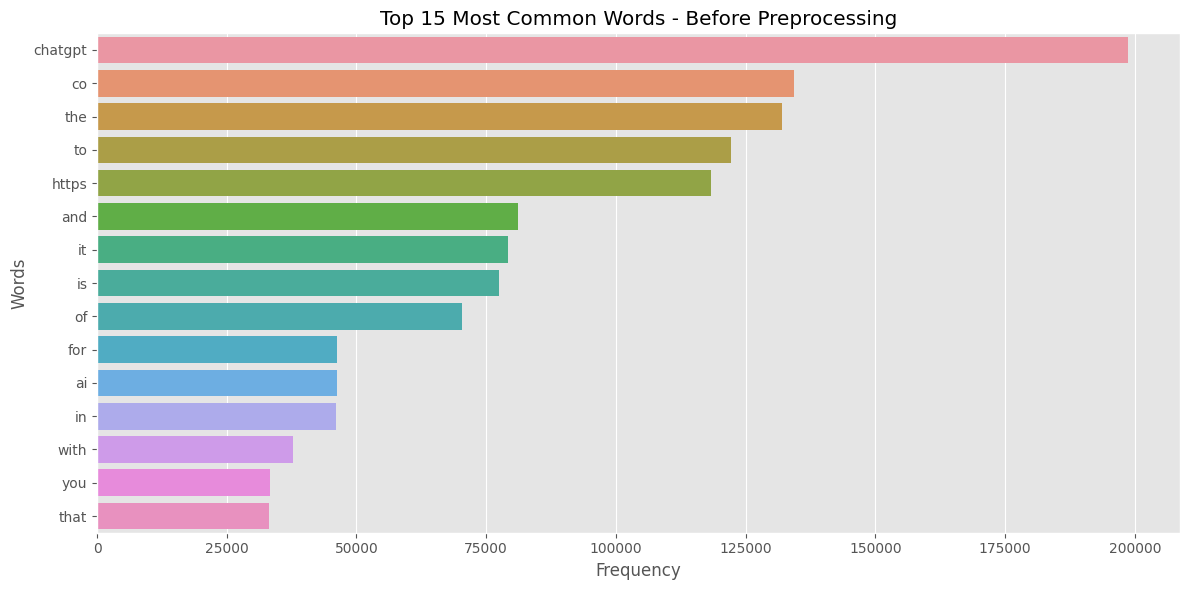

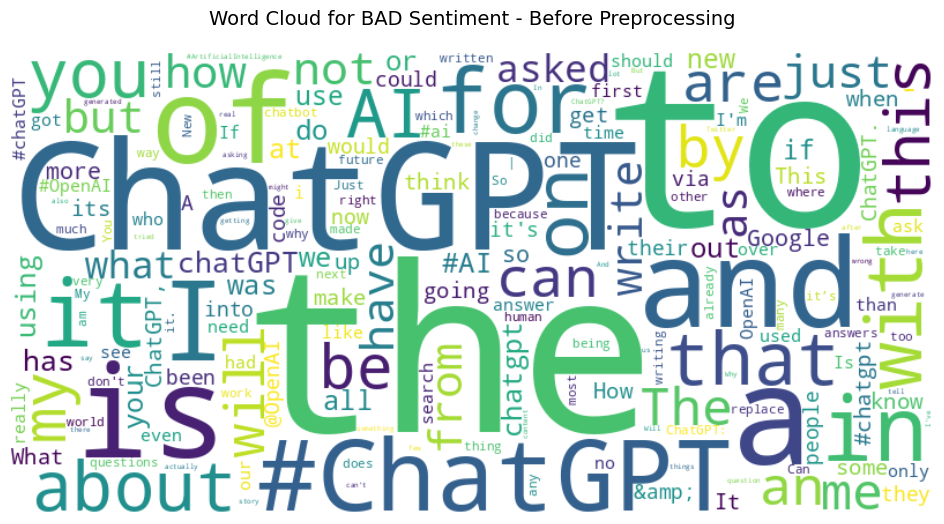

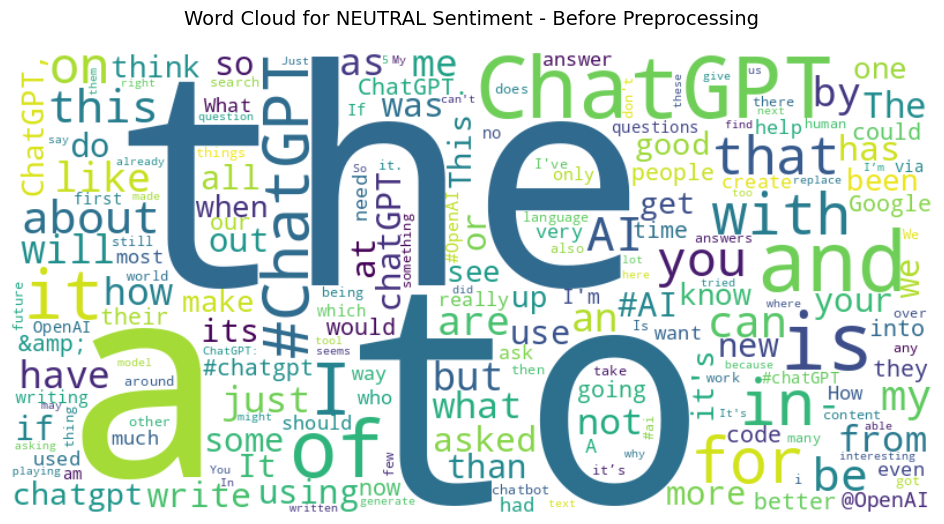

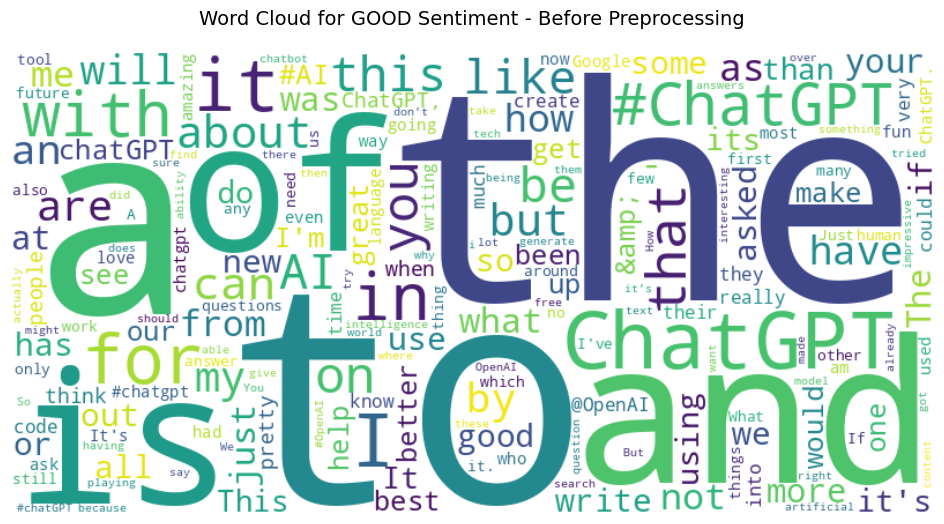

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


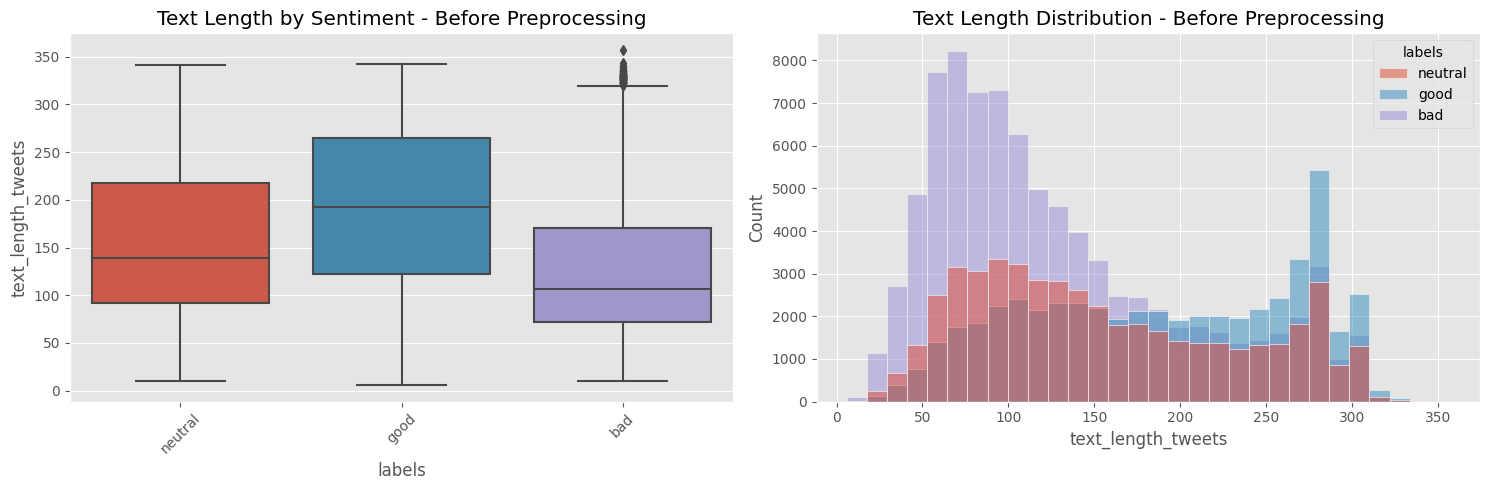


==================== Analysis for After Preprocessing ====================

Sentiment Distribution:
labels
bad        46.47
good       27.71
neutral    25.82
Name: proportion, dtype: float64

Average text length by sentiment:
          mean  count    std
labels                      
bad      56.22  87159  41.03
good     90.54  51976  44.14
neutral  70.96  48419  42.60

Top 10 words for bad sentiment:
not: 13577
write: 9688
use: 9640
ask: 8642
get: 5989
make: 5104
go: 4942
think: 4569
can: 4358
new: 4179

Top 10 words for neutral sentiment:
not: 9149
use: 6662
write: 5802
like: 5275
ask: 5208
get: 3885
make: 3337
can: 3035
well: 3021
think: 2994

Top 10 words for good sentiment:
not: 11353
use: 8647
like: 8464
write: 6887
good: 6543
ask: 6209
get: 4880
make: 4836
well: 4658
more: 4131

Sample texts for each sentiment:

BAD sentiment samples:
1. ask write song style bob dylan work hardcore elon musk think put music...
2. move accurate professional human clinician gptchat gptwitter...

G

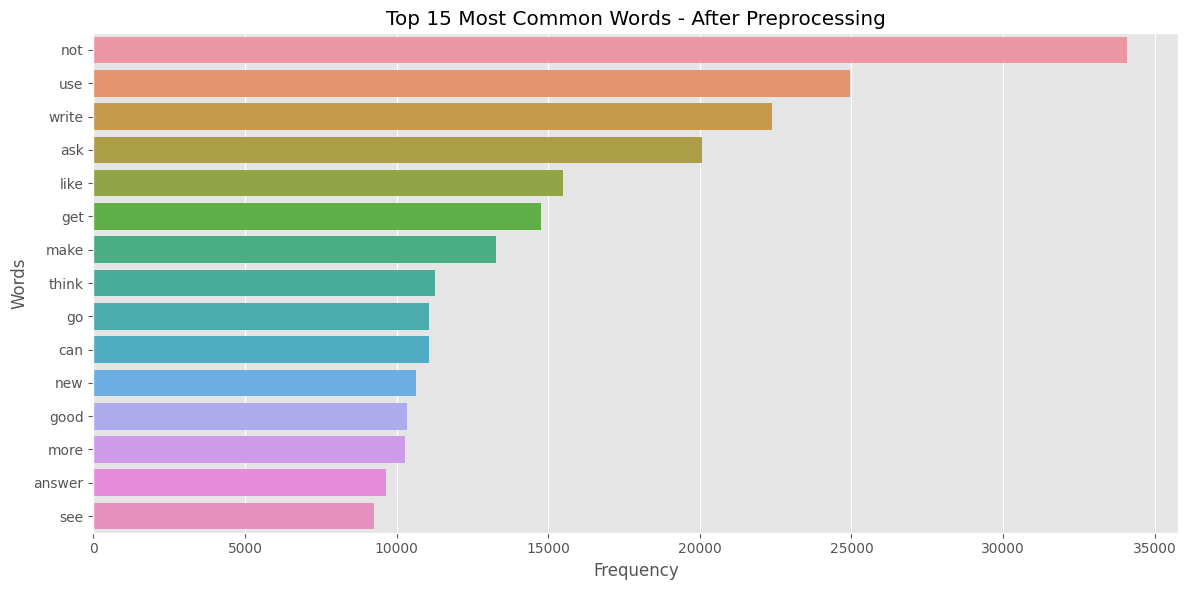

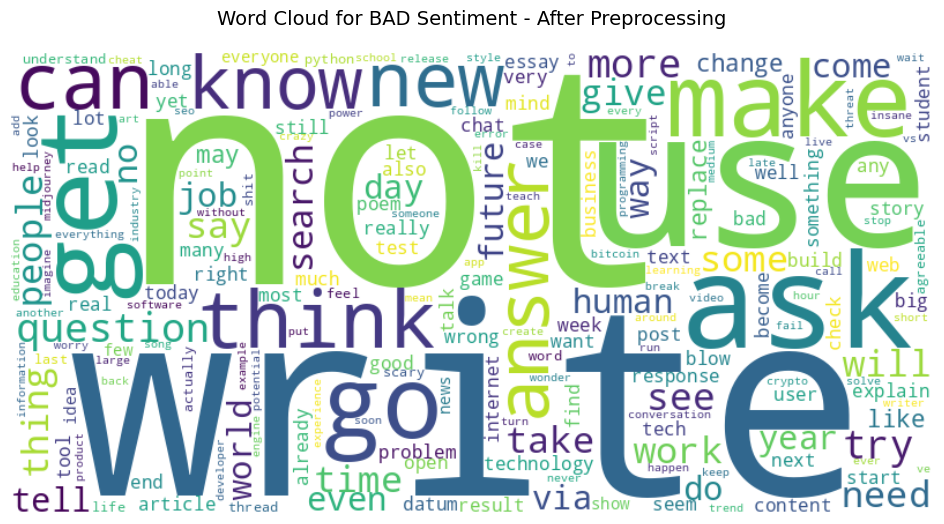

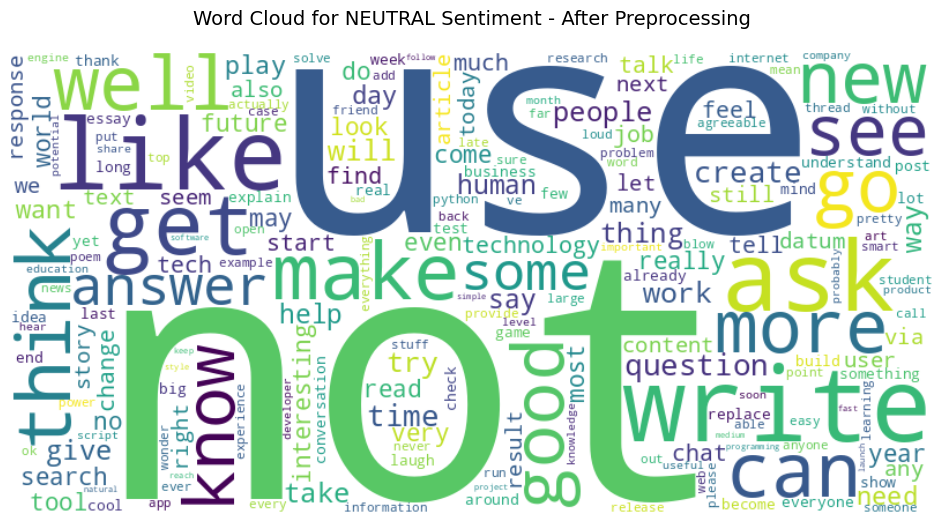

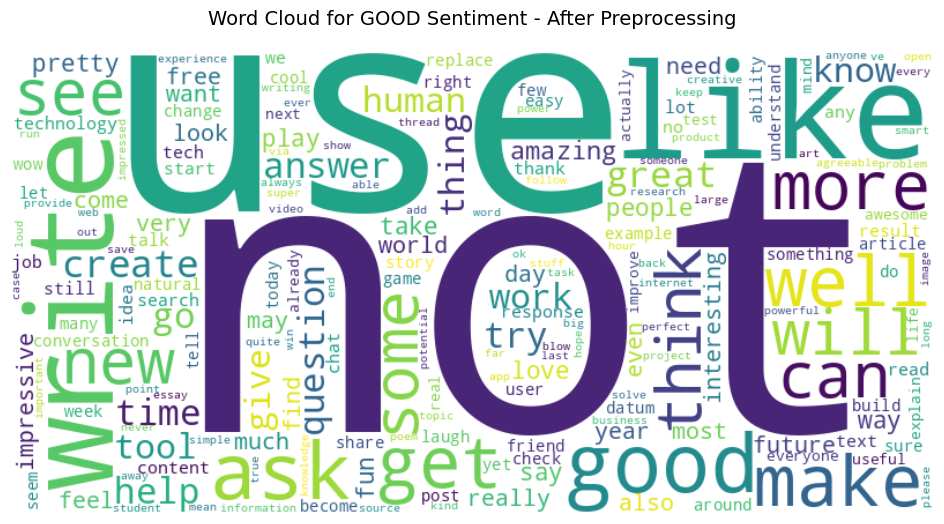

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


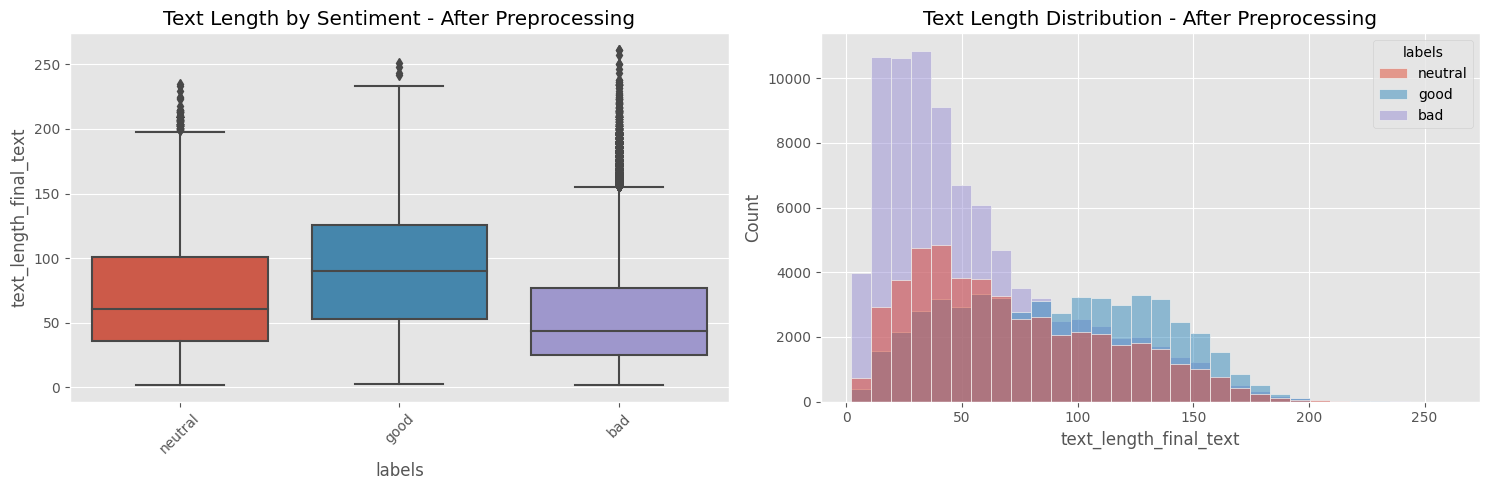

In [ ]:
# Melakukan semua proses EDA pada dataset
analyze_text_preprocessing(df)

## 1. **Analisis Distribusi Sentimen**
- **Distribusi Utama**:
  - **Sentimen Negatif (46.47%)**: Mencerminkan skeptisisme dan kritik yang tinggi terhadap teknologi ChatGPT.
  - **Sentimen Positif (27.71%)**: Menunjukkan apresiasi terhadap kemampuan dan manfaat teknologi.
  - **Sentimen Netral (25.82%)**: Mengindikasikan diskusi objektif dan evaluasi seimbang.

- **Implikasi**:
  - Dominasi sentimen negatif menunjukkan adanya kekhawatiran publik terhadap dampak dan keterbatasan ChatGPT, namun tetap diimbangi dengan pengakuan positif atas potensinya.

---

## 2. **Analisis Panjang Teks**
- **Sebelum Preprocessing**:
  - **Sentimen Positif**: 189.43 karakter – Elaborasi pengalaman positif.
  - **Sentimen Netral**: 155.30 karakter – Keseimbangan pandangan objektif.
  - **Sentimen Negatif**: 129.04 karakter – Kritik singkat dan langsung.

- **Setelah Preprocessing**:
  - **Sentimen Positif**: 90.54 karakter – Pola elaboratif tetap bertahan.
  - **Sentimen Netral**: 70.96 karakter – Pengurangan elemen non-esensial.
  - **Sentimen Negatif**: 56.22 karakter – Kritik lebih langsung dan terfokus.

---

## 3. **Analisis Kata-kata Frekuensi Tinggi**
- **Sebelum Preprocessing**:
  - **Sentimen Negatif**: Dominasi kata "the", "to", "ChatGPT" menunjukkan fokus pada subjek kritik.
  - **Sentimen Positif**: Fokus pada manfaat dan aplikasi teknologi.
  - **Sentimen Netral**: Penggunaan istilah teknis mencerminkan diskusi mendalam.

- **Setelah Preprocessing**:
  - **Sentimen Negatif**: Dominasi kata "not" (13,577) menunjukkan tingginya kritik berbasis pengalaman.
  - **Sentimen Positif**: Kombinasi "good", "like" dengan evaluasi apresiatif.
  - **Sentimen Netral**: Kata-kata aksi seperti "use" dan "write" menunjukkan fokus pada fungsionalitas.

---

## 4. **Analisis Mendalam Visualisasi**

### 4.1 **Word Clouds**
- **Sebelum Preprocessing**: Kompleksitas struktur mengungkapkan keragaman sudut pandang.
- **Setelah Preprocessing**: Fokus pada inti persepsi publik dengan pola yang lebih jelas.

### 4.2 **Box Plot**
#### 4.2.1 **Analisis Box Plot Sebelum Preprocessing**
- **Karakteristik Distribusi**:
  - **Sentimen Negatif (Bad)**:
    - Median: ~120 karakter  
    - Range: Tersebar antara 50-200 karakter  
    - Outliers: Beberapa teks ekstrem mencapai >250 karakter  
    - **Interpretasi:** Kritik cenderung singkat dan langsung.

  - **Sentimen Positif (Good)**:
    - Median: ~180 karakter  
    - Range: Tersebar luas antara 100-250 karakter  
    - Outliers: Banyak outliers di atas 300 karakter  
    - **Interpretasi:** Apresiasi cenderung lebih deskriptif dan detail.

  - **Sentimen Netral**:
    - Median: ~150 karakter  
    - Range: Moderat antara 75-225 karakter  
    - Outliers: Beberapa outliers di kedua ekstrem  
    - **Interpretasi:** Komentar objektif memiliki panjang moderat.

- **Perbandingan Antar Sentimen**:
  - Perbedaan median signifikan (60 karakter antara positif dan negatif).  
  - Variasi paling tinggi pada sentimen positif.  
  - Distribusi teks cenderung **right-skewed** untuk semua kategori.  

#### 4.2.2 **Analisis Box Plot Setelah Preprocessing**
- **Karakteristik Distribusi**:
  - **Sentimen Negatif (Bad)**:
    - Median: ~50 karakter  
    - Range: Lebih sempit, 25-100 karakter  
    - Outliers: Berkurang signifikan  
    - **Interpretasi:** Pembersihan efektif menyederhanakan kritik.

  - **Sentimen Positif (Good)**:
    - Median: ~85 karakter  
    - Range: 50-150 karakter  
    - Outliers: Masih ada namun lebih terkontrol  
    - **Interpretasi:** Tetap lebih panjang meski sudah dibersihkan.

  - **Sentimen Netral**:
    - Median: ~65 karakter  
    - Range: 35-120 karakter  
    - Outliers: Minimal  
    - **Interpretasi:** Preprocessing menghasilkan teks yang lebih fokus.

- **Perbandingan Pasca Preprocessing**:
  - Gap median antar sentimen berkurang (35 karakter).  
  - Variasi lebih terkontrol di semua kategori.  
  - Distribusi lebih mendekati **normal**.  

#### 4.2.3 **Implikasi untuk Analisis**
- **Dampak Preprocessing**:
  - **Pengurangan Noise**:
    - Berhasil (~50% pengurangan panjang).  
    - Standardisasi teks lebih efektif.  
    - Outliers terkendali tanpa menghilangkan karakteristik sentimen.  

- **Keuntungan untuk Modeling**:
  - Distribusi lebih seragam mendukung proses training.  
  - Range yang terkontrol mengurangi risiko bias.  
  - Karakteristik sentimen tetap terjaga meski teks lebih pendek.  

- **Insight Penting**:
  - Pola panjang teks konsisten sebelum dan sesudah preprocessing.  
  - Sentimen positif tetap lebih elaboratif.  
  - Preprocessing berhasil mempertahankan perbedaan karakteristik antar sentimen.

---

## 5. **Kesimpulan Utama**
### 5.1 **Efektivitas Preprocessing**
- **Pengurangan Panjang Teks**: ~50% menunjukkan tingginya noise dalam data asli.
- **Peningkatan Kualitas Analisis**: Fokus pada konten substansial, mengurangi redundansi.

### 5.2 **Temuan Kunci**
- Dominasi kritik (46.47%) menunjukkan sikap hati-hati publik.
- Elaborasi lebih panjang pada teks positif mencerminkan apresiasi yang mendalam.
- Tingginya penggunaan "not" menunjukkan evaluasi kritis di semua sentimen.
- Volume data memadai (187,554 tweets).
- Pengurangan noise ~50% (rata-rata panjang teks dari 157.92 ke 72.57 karakter).
- Format teks terstandarisasi dan konsisten.
- Penghapusan duplikasi berhasil.
- Ketidakseimbangan kelas masih wajar (46.47% : 27.71% : 25.82%).
- Standard deviation panjang teks menurun 45%
- Pola kata kunci untuk setiap sentimen jelas.
- Outliers teridentifikasi dan terkontrol.
- Tidak ada missing values.

### 5.3 **Kesimpulan Umum**:
- Dataset telah siap untuk proses modeling klasifikasi multi-kelas.
- Pendekatan **traditional ML** atau **deep learning** dapat digunakan.
---

### Vectorization Process (Text Representation)

In [ ]:
# Label mapping
label_map = {'bad': 0, 'neutral': 1, 'good': 2}
y = df['labels'].map(label_map)

In [ ]:
# TF-IDF Vectorization for ML Models
tfidf = TfidfVectorizer(max_features=10000)
print("\nVectorizing text with TF-IDF...")
with tqdm(total=1) as pbar:
    X = tfidf.fit_transform(df['final_text'])
    pbar.update(1)


Vectorizing text with TF-IDF...


100%|██████████| 1/1 [00:01<00:00,  1.96s/it]


In [ ]:
# Splitting: 70% Train, 15% Validation, 15% Test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.30,    # 30% untuk test
    random_state=SEED, # Seed untuk reproducibility
    stratify=y         # Stratifikasi berdasarkan y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.50,  # half of 30% → 15%
    random_state=SEED,   # Seed untuk reproducibility
    stratify=y_trainval  # Stratifikasi berdasarkan y_trainval
)

# Cetak ukuran dataset setelah pembagian
print(f"\n[Classical ML] Data shapes:")
print(f"  Train:      {X_train.shape}, {y_train.shape}") # Data training
print(f"  Validation: {X_val.shape},   {y_val.shape}")   # Data validation
print(f"  Test:       {X_test.shape},  {y_test.shape}")  # Data test


[Classical ML] Data shapes:
  Train:      (65643, 10000), (65643,)
  Validation: (65644, 10000),   (65644,)
  Test:       (56267, 10000),  (56267,)


In [ ]:
def plot_confusion_matrix_matplotlib(y_true, y_pred, model_name=""):
    """
    Plots a confusion matrix using plain Matplotlib.
    """
     # Menghitung confusion matrix menggunakan fungsi confusion_matrix dari sklearn
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, cmap='Blues')
    plt.title(f'{model_name} Confusion Matrix')
    plt.colorbar()
    num_labels = cm.shape[0]
    plt.xticks(range(num_labels), range(num_labels))
    plt.yticks(range(num_labels), range(num_labels))
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    thresh = cm.max() / 2.
    for i in range(num_labels):
        for j in range(num_labels):
            plt.text(
                j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )
    plt.tight_layout()
    plt.show()

def plot_learning_curves(model, X_train, X_val, y_train, y_val, model_name):
    """
    Simple incremental training curve for classical ML models.
    """
    train_sizes = np.linspace(0.1, 1.0, 5)
    train_scores = []
    val_scores = []

    n_samples = X_train.shape[0]

    for size in train_sizes:
        subset_size = int(n_samples * size)
        X_subset = X_train[:subset_size]
        y_subset = y_train[:subset_size]
        model.fit(X_subset, y_subset)

        train_score = model.score(X_subset, y_subset)
        val_score = model.score(X_val, y_val)

        train_scores.append(train_score)
        val_scores.append(val_score)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_scores, label='Training score', marker='o')
    plt.plot(train_sizes, val_scores, label='Validation score', marker='o')
    plt.xlabel('Fraction of Training Set')
    plt.ylabel('Accuracy')
    plt.title(f'{model_name} Learning Curves')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_nn_training_history(history):
    """
    Plots training and validation (loss & accuracy) over epochs for NN-based training.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Plot Loss
    ax1.plot(history['train_losses'], label='Training Loss', marker='o')
    ax1.plot(history['val_losses'], label='Validation Loss', marker='o')
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # Plot Accuracy
    ax2.plot(history['train_accuracies'], label='Training Accuracy', marker='o')
    ax2.plot(history['val_accuracies'], label='Validation Accuracy', marker='o')
    ax2.set_title('Training and Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


### Modelling and Experimentation

#### ML: Training & Evaluation

In [ ]:
def train_evaluate_model(model, X_train, X_val, y_train, y_val, model_name):
    print(f"\n--- Training {model_name} ---")
    with tqdm(total=1) as pbar:
        model.fit(X_train, y_train)
        pbar.update(1)

    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    print(f"{model_name} Accuracy (Val): {accuracy:.3f}")
    print(f"{model_name} Classification Report (Val):")
    print(classification_report(y_val, y_pred))

    # Confusion Matrix
    plot_confusion_matrix_matplotlib(y_val, y_pred, model_name=f"{model_name} (Val)")

    # ROC & AUC
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_val)
    else:
        # For linear SVM with decision_function
        y_scores = model.decision_function(X_val)
        # Convert decision_function scores to probabilities via softmax
        y_prob = np.exp(y_scores) / np.sum(np.exp(y_scores), axis=1, keepdims=True)

    n_classes = len(np.unique(y_val))
    plt.figure(figsize=(8, 6))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_val == i, y_prob[:, i])
        roc_auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc_val:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} ROC Curves (Val)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Macro-average
    fpr = dict()
    tpr = dict()
    roc_auc_dict = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_val == i, y_prob[:, i])
        roc_auc_dict[i] = auc(fpr[i], tpr[i])
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    macro_roc_auc = auc(all_fpr, mean_tpr)

    print(f"Macro-average ROC AUC (Val): {macro_roc_auc:.3f}")
    plt.figure(figsize=(8, 6))
    plt.plot(all_fpr, mean_tpr, label=f'Macro-Average AUC = {macro_roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} Macro-Average ROC (Val)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Learning Curves
    plot_learning_curves(model, X_train, X_val, y_train, y_val, model_name)
    return macro_roc_auc

#### Hyperparameter Tuning for ML Models

In [ ]:
model_configs = {
    'SVM': {
        'model': LinearSVC(random_state=SEED),
        'params': {
            'C': [0.1, 1, 10],
            'max_iter': [1000]
        }
    },
    'Logistic Regression': {
        'model': LogisticRegression(random_state=SEED, max_iter=2000),
        'params': {
            'C': [0.1, 1, 10],
            'solver': ['lbfgs', 'liblinear']
        }
    },
    'Naive Bayes': {
        'model': MultinomialNB(),
        'params': {
            'alpha': [0.1, 1.0, 2.0]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=SEED, use_label_encoder=False, eval_metric='logloss'),
        'params': {
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1],
            'n_estimators': [100, 200]
        }
    }
}

def train_evaluate_with_tuning(model_config, X_train, X_val, y_train, y_val, model_name):
    """
    Train base model, evaluate, then do GridSearchCV, evaluate tuned model.
    """
    print(f"\n=== {model_name}: Base Model ===")
    base_model = model_config['model']
    base_model.fit(X_train, y_train)
    base_auc = train_evaluate_model(base_model, X_train, X_val, y_train, y_val, f"{model_name} (Base)")

    print(f"\n=== {model_name}: Hyperparameter Tuning ===")
    grid_search = GridSearchCV(
        estimator=model_config['model'],
        param_grid=model_config['params'],
        cv=3,
        scoring='f1_weighted',
        n_jobs=-1
    )
    with tqdm(total=1) as pbar:
        grid_search.fit(X_train, y_train)
        pbar.update(1)
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best CV Score (f1_weighted): {grid_search.best_score_:.3f}")

    tuned_model = grid_search.best_estimator_
    tuned_auc = train_evaluate_model(tuned_model, X_train, X_val, y_train, y_val, f"{model_name} (Tuned)")

    print(f"\n{model_name} AUC Comparison:")
    print(f"  Base Model  - AUC: {base_auc:.3f}")
    print(f"  Tuned Model - AUC: {tuned_auc:.3f}")

    return tuned_model

##### Evaluate Classical Models on Test Set

In [ ]:
def evaluate_on_test(model, X_test, y_test, model_name):
    """
    Evaluate a (fitted) model on the Test set (15%).
    """
    print(f"\n--- {model_name} on TEST SET ---")
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy (Test): {accuracy:.3f}")
    print("Classification Report (Test):")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    plot_confusion_matrix_matplotlib(y_test, y_pred, model_name=f"{model_name} (Test)")

    # Probability or decision_function for ROC
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)
    else:
        y_scores = model.decision_function(X_test)
        y_prob = np.exp(y_scores) / np.sum(np.exp(y_scores), axis=1, keepdims=True)

    n_classes = len(np.unique(y_test))
    roc_auc_dict = {}
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test == i, y_prob[:, i])
        roc_auc_dict[i] = auc(fpr, tpr)
    final_auc = np.mean(list(roc_auc_dict.values()))
    print(f"{model_name} Macro-Average AUC (Test): {final_auc:.3f}")
    return final_auc

#### Run All ML Models

In [ ]:
def run_classical_models(X_train, X_val, X_test, y_train, y_val, y_test):
    """
    Train, tune, and evaluate each classical model with 70/15/15 splits.
    """
    best_models = {}
    final_results = {}

    for name, config in model_configs.items():
        print(f"\nProcessing {name} ...")
        best_models[name] = train_evaluate_with_tuning(config, X_train, X_val, y_train, y_val, name)

    print("\n=== Final Model Comparison on Test Set ===")
    for name, model in best_models.items():
        final_auc = evaluate_on_test(model, X_test, y_test, name)
        final_results[name] = final_auc

    print("\n--- Final Macro-Average AUC (Test) ---")
    for name, score in final_results.items():
        print(f"{name}: {score:.3f}")

    # Optionally, pick your best model and save it
    # with open("best_model.pkl", "wb") as f:
    #     pickle.dump(best_models['Logistic Regression'], f)

    return best_models, final_results

#### LSTM

In [ ]:
def build_vocabulary(texts, min_freq=1):
    """
    Builds a vocabulary dictionary mapping each token to an integer index.
    """
    token_freq = {}
    for text in texts:
        tokens = text.lower().split()
        for token in tokens:
            token_freq[token] = token_freq.get(token, 0) + 1

    sorted_tokens = sorted(token_freq.items(), key=lambda x: x[1], reverse=True)
    vocab2idx = {"<PAD>": 0, "<UNK>": 1}
    idx2vocab = ["<PAD>", "<UNK>"]

    for token, freq in sorted_tokens:
        if freq >= min_freq:
            vocab2idx[token] = len(vocab2idx)
            idx2vocab.append(token)

    return vocab2idx, idx2vocab

def text_to_sequence_lstm(text, vocab2idx, max_length=50):
    """
    Converts text to a list of token indices based on vocab2idx.
    """
    tokens = text.lower().split()
    sequence = []
    for token in tokens:
        if token in vocab2idx:
            sequence.append(vocab2idx[token])
        else:
            sequence.append(vocab2idx["<UNK>"])
    if len(sequence) > max_length:
        sequence = sequence[:max_length]
    else:
        sequence += [vocab2idx["<PAD>"]] * (max_length - len(sequence))
    return sequence

class LSTMDataset(Dataset):
    """
    Dataset for LSTM-based text classification
    """
    def __init__(self, texts, labels, vocab2idx, max_length=50):
        self.texts = texts
        self.labels = labels
        self.vocab2idx = vocab2idx
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        sequence = text_to_sequence_lstm(text, self.vocab2idx, self.max_length)
        return {
            'input_ids': torch.tensor(sequence, dtype=torch.long),
            'label': torch.tensor(label, dtype=torch.long)
        }

class LSTMClassifier(nn.Module):
    """
    LSTM-based classifier
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_classes, n_layers=1, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers,
                            batch_first=True, bidirectional=False)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, n_classes)

    def forward(self, input_ids):
        embeds = self.embedding(input_ids)
        lstm_out, (h_n, c_n) = self.lstm(embeds)
        last_hidden = h_n[-1]
        dropped = self.dropout(last_hidden)
        logits = self.fc(dropped)
        return logits

class EarlyStoppingLSTM:
    """
    Early stopping for LSTM
    """
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0
        return self.early_stop

class LSTMTrainer:
    """
    Trainer class for LSTM
    """
    def __init__(self, model, device, patience=5, lr=1e-3):
        self.model = model
        self.device = device
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.1, patience=2, verbose=True
        )
        self.early_stopping = EarlyStoppingLSTM(patience=patience)
        self.max_grad_norm = 5.0

    def train_epoch(self, dataloader):
        self.model.train()
        total_loss = 0
        correct = 0
        total = 0
        progress_bar = tqdm(dataloader, desc='[LSTM Training]', leave=False)

        for batch in progress_bar:
            input_ids = batch['input_ids'].to(self.device)
            labels = batch['label'].to(self.device)

            self.optimizer.zero_grad()
            outputs = self.model(input_ids)
            loss = self.criterion(outputs, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), self.max_grad_norm)
            self.optimizer.step()

            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            progress_bar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{correct / total:.4f}'})
        return total_loss / len(dataloader), correct / total

    def evaluate(self, dataloader):
        self.model.eval()
        total_loss = 0
        correct = 0
        total = 0
        progress_bar = tqdm(dataloader, desc='[LSTM Evaluating]', leave=False)
        with torch.no_grad():
            for batch in progress_bar:
                input_ids = batch['input_ids'].to(self.device)
                labels = batch['label'].to(self.device)

                outputs = self.model(input_ids)
                loss = self.criterion(outputs, labels)

                total_loss += loss.item()
                preds = torch.argmax(outputs, dim=-1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

                progress_bar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{correct / total:.4f}'})
        return total_loss / len(dataloader), correct / total

    def train(self, train_loader, val_loader, epochs=5):
        history = {
            'train_losses': [],
            'val_losses': [],
            'train_accuracies': [],
            'val_accuracies': []
        }
        best_val_loss = float('inf')
        best_state = None

        for epoch in range(epochs):
            print(f"\n[LSTM] Epoch {epoch+1}/{epochs}")
            train_loss, train_acc = self.train_epoch(train_loader)
            val_loss, val_acc = self.evaluate(val_loader)
            self.scheduler.step(val_loss)

            print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
            print(f"  Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.4f}")

            history['train_losses'].append(train_loss)
            history['val_losses'].append(val_loss)
            history['train_accuracies'].append(train_acc)
            history['val_accuracies'].append(val_acc)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = self.model.state_dict().copy()

            if self.early_stopping(val_loss):
                print("[LSTM] Early stopping triggered!")
                break

        if best_state is not None:
            self.model.load_state_dict(best_state)
        return history


def run_lstm_pipeline():
    """
    Full pipeline for LSTM with 70/15/15 splits.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print("\n--- LSTM Pipeline ---")
    df_lstm = pd.read_csv("preprocessed_a1.csv")
    df_lstm.dropna(subset=['final_text'], inplace=True)
    label_map_lstm = {'bad':0, 'neutral':1, 'good':2}
    texts = df_lstm['final_text'].astype(str).tolist()
    labels = df_lstm['labels'].map(label_map_lstm).tolist()

    # 70% vs 30%
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        texts, labels,
        test_size=0.30,
        random_state=SEED,
        stratify=labels
    )
    # 15% vs 15%
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval,
        test_size=0.50,
        random_state=SEED,
        stratify=y_trainval
    )

    vocab2idx, idx2vocab = build_vocabulary(X_train, min_freq=1)
    train_dataset = LSTMDataset(X_train, y_train, vocab2idx)
    val_dataset = LSTMDataset(X_val, y_val, vocab2idx)
    test_dataset = LSTMDataset(X_test, y_test, vocab2idx)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32)
    test_loader = DataLoader(test_dataset, batch_size=32)

    model = LSTMClassifier(
        vocab_size=len(vocab2idx),
        embed_dim=100,
        hidden_dim=128,
        n_classes=len(label_map_lstm),
        n_layers=1,
        dropout=0.5
    ).to(device)

    trainer = LSTMTrainer(model, device, patience=5, lr=1e-3)
    history = trainer.train(train_loader, val_loader, epochs=5)
    plot_nn_training_history(history)

    # Evaluate on Test
    test_loss, test_acc = trainer.evaluate(test_loader)
    print(f"\n[LSTM] Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

    # Confusion matrix
    all_preds = []
    all_labels = []
    model.eval()
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            labels_ = batch['label'].to(device)
            outputs = model(input_ids)
            preds = torch.argmax(outputs, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels_.cpu().numpy())
    print("\n[LSTM] Classification Report (Test):")
    print(classification_report(all_labels, all_preds, target_names=list(label_map_lstm.keys())))
    plot_confusion_matrix_matplotlib(all_labels, all_preds, model_name="[LSTM]")


#### CNN

In [ ]:
def text_to_sequence_cnn(text, vocab2idx, max_length=50):
    tokens = text.lower().split()
    seq = []
    for token in tokens:
        seq.append(vocab2idx.get(token, vocab2idx["<UNK>"]))
    if len(seq) > max_length:
        seq = seq[:max_length]
    else:
        seq += [vocab2idx["<PAD>"]] * (max_length - len(seq))
    return seq

class TextDatasetCNN(Dataset):
    def __init__(self, texts, labels, vocab2idx, max_length=50):
        self.texts = texts
        self.labels = labels
        self.vocab2idx = vocab2idx
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        seq = text_to_sequence_cnn(text, self.vocab2idx, self.max_length)
        return {
            'input_ids': torch.tensor(seq, dtype=torch.long),
            'label': torch.tensor(label, dtype=torch.long)
        }

class CNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_filters, n_classes, kernel_sizes=[3,4,5], dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=ks)
            for ks in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), n_classes)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)  # (batch_size, seq_len, embed_dim)
        embedded = embedded.permute(0, 2, 1)  # (batch_size, embed_dim, seq_len)

        convs = [torch.relu(conv(embedded)) for conv in self.convs]
        pooled = [torch.max(c, dim=2)[0] for c in convs]
        cat = torch.cat(pooled, dim=1)
        cat = self.dropout(cat)
        logits = self.fc(cat)
        return logits

class EarlyStoppingCNN:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0
        return self.early_stop

class CNNTrainer:
    def __init__(self, model, device, patience=5, lr=1e-3):
        self.model = model
        self.device = device
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.1, patience=2, verbose=True
        )
        self.early_stopping = EarlyStoppingCNN(patience=patience)
        self.max_grad_norm = 5.0

    def train_epoch(self, dataloader):
        self.model.train()
        total_loss = 0
        correct = 0
        total = 0
        progress_bar = tqdm(dataloader, desc='[CNN Training]', leave=False)
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(self.device)
            labels = batch['label'].to(self.device)
            self.optimizer.zero_grad()
            outputs = self.model(input_ids)
            loss = self.criterion(outputs, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), self.max_grad_norm)
            self.optimizer.step()

            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            progress_bar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{correct/total:.4f}'})
        return total_loss / len(dataloader), correct / total

    def evaluate(self, dataloader):
        self.model.eval()
        total_loss = 0
        correct = 0
        total = 0
        progress_bar = tqdm(dataloader, desc='[CNN Evaluating]', leave=False)
        with torch.no_grad():
            for batch in progress_bar:
                input_ids = batch['input_ids'].to(self.device)
                labels = batch['label'].to(self.device)
                outputs = self.model(input_ids)
                loss = self.criterion(outputs, labels)
                total_loss += loss.item()
                preds = torch.argmax(outputs, dim=-1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
                progress_bar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{correct/total:.4f}'})
        return total_loss / len(dataloader), correct / total

    def train(self, train_loader, val_loader, epochs=5):
        history = {
            'train_losses': [],
            'val_losses': [],
            'train_accuracies': [],
            'val_accuracies': []
        }
        best_val_loss = float('inf')
        best_state = None

        for epoch in range(epochs):
            print(f"\n[CNN] Epoch {epoch+1}/{epochs}")
            train_loss, train_acc = self.train_epoch(train_loader)
            val_loss, val_acc = self.evaluate(val_loader)
            self.scheduler.step(val_loss)

            print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
            print(f"  Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.4f}")

            history['train_losses'].append(train_loss)
            history['val_losses'].append(val_loss)
            history['train_accuracies'].append(train_acc)
            history['val_accuracies'].append(val_acc)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = self.model.state_dict().copy()

            if self.early_stopping(val_loss):
                print("[CNN] Early stopping triggered!")
                break

        if best_state is not None:
            self.model.load_state_dict(best_state)
        return history


def run_cnn_pipeline():
    """
    Full pipeline for CNN with 70/15/15 splits.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print("\n--- CNN Pipeline ---")
    df_cnn = pd.read_csv("preprocessed_a1.csv")
    df_cnn.dropna(subset=['final_text'], inplace=True)
    label_map_cnn = {'bad':0, 'neutral':1, 'good':2}
    texts = df_cnn['final_text'].astype(str).tolist()
    labels = df_cnn['labels'].map(label_map_cnn).tolist()

    # 70% vs 30%
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        texts, labels,
        test_size=0.30,
        random_state=SEED,
        stratify=labels
    )
    # 15% vs 15%
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval,
        test_size=0.50,
        random_state=SEED,
        stratify=y_trainval
    )

    vocab2idx_cnn, idx2vocab_cnn = build_vocabulary(X_train, min_freq=1)
    train_dataset = TextDatasetCNN(X_train, y_train, vocab2idx_cnn)
    val_dataset = TextDatasetCNN(X_val, y_val, vocab2idx_cnn)
    test_dataset = TextDatasetCNN(X_test, y_test, vocab2idx_cnn)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32)
    test_loader = DataLoader(test_dataset, batch_size=32)

    model = CNNClassifier(
        vocab_size=len(vocab2idx_cnn),
        embed_dim=100,
        num_filters=100,
        n_classes=len(label_map_cnn),
        kernel_sizes=[3,4,5],
        dropout=0.5
    ).to(device)

    trainer = CNNTrainer(model, device, patience=5, lr=1e-3)
    history = trainer.train(train_loader, val_loader, epochs=5)
    plot_nn_training_history(history)

    # Evaluate on Test
    test_loss, test_acc = trainer.evaluate(test_loader)
    print(f"\n[CNN] Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

    # Confusion matrix
    all_preds = []
    all_labels = []
    model.eval()
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            labels_ = batch['label'].to(device)
            outputs = model(input_ids)
            preds = torch.argmax(outputs, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels_.cpu().numpy())

    print("\n[CNN] Classification Report (Test):")
    print(classification_report(all_labels, all_preds, target_names=list(label_map_cnn.keys())))
    plot_confusion_matrix_matplotlib(all_labels, all_preds, model_name="[CNN]")

#### BERT

In [ ]:
def text_to_sequence_bert(text, tokenizer, max_length=128):
    return tokenizer(
        text,
        add_special_tokens=True,
        max_length=max_length,
        truncation=True,
        padding='max_length',
        return_tensors='pt',
        return_attention_mask=True,
        return_token_type_ids=False
    )

class MultiClassDatasetbert(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = text_to_sequence_bert(text, self.tokenizer, self.max_length)
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

class bertClassifier(nn.Module):
    def __init__(self, n_classes, dropout=0.3):
        super().__init__()
        self.config = AutoConfig.from_pretrained("bert-base-uncased", num_labels=n_classes)
        self.bert = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", config=self.config)
        self.dropout = nn.Dropout(dropout)
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=None
        )
        return outputs.logits

class EarlyStoppingbert:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0
        return self.early_stop

class bertTrainer:
    def __init__(self, model, device, patience=5, lr=2e-5):
        self.model = model
        self.device = device
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.1, patience=2, verbose=True
        )
        self.early_stopping = EarlyStoppingbert(patience=patience)
    def train_epoch(self, dataloader):
        self.model.train()
        total_loss, correct, total = 0, 0, 0
        progress_bar = tqdm(dataloader, desc='[bert Training]', leave=False)
        for batch in progress_bar:
            self.optimizer.zero_grad()
            input_ids = batch['input_ids'].to(self.device)
            attention_mask = batch['attention_mask'].to(self.device)
            labels = batch['label'].to(self.device)
            logits = self.model(input_ids, attention_mask)
            loss = self.criterion(logits, labels)
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            progress_bar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{correct/total:.4f}'})
        return total_loss/len(dataloader), correct/total

    def evaluate(self, dataloader):
        self.model.eval()
        total_loss, correct, total = 0, 0, 0
        progress_bar = tqdm(dataloader, desc='[bert Evaluating]', leave=False)
        with torch.no_grad():
            for batch in progress_bar:
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['label'].to(self.device)
                logits = self.model(input_ids, attention_mask)
                loss = self.criterion(logits, labels)

                total_loss += loss.item()
                preds = torch.argmax(logits, dim=-1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
                progress_bar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{correct/total:.4f}'})
        return total_loss/len(dataloader), correct/total

    def train(self, train_loader, val_loader, epochs=3):
        history = {
            'train_losses': [],
            'val_losses': [],
            'train_accuracies': [],
            'val_accuracies': []
        }
        best_val_loss = float('inf')
        best_state = None

        for epoch in range(epochs):
            print(f"\n[bert] Epoch {epoch+1}/{epochs}")
            train_loss, train_acc = self.train_epoch(train_loader)
            val_loss, val_acc = self.evaluate(val_loader)
            self.scheduler.step(val_loss)

            print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
            print(f"  Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.4f}")

            history['train_losses'].append(train_loss)
            history['val_losses'].append(val_loss)
            history['train_accuracies'].append(train_acc)
            history['val_accuracies'].append(val_acc)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = self.model.state_dict().copy()

            if self.early_stopping(val_loss):
                print("[bert] Early stopping triggered!")
                break

        if best_state is not None:
            self.model.load_state_dict(best_state)
        return history

def run_bert_pipeline():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print("\n--- bert Pipeline ---")
    df_bert = pd.read_csv("preprocessed_a1.csv")
    df_bert.dropna(subset=['final_text'], inplace=True)
    label_map_bert = {'bad':0, 'neutral':1, 'good':2}
    texts = df_bert['final_text'].tolist()
    labels = df_bert['labels'].map(label_map_bert).tolist()

    # 70 vs 30
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        texts, labels,
        test_size=0.30,
        random_state=SEED,
        stratify=labels
    )
    # 15 vs 15
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval,
        test_size=0.50,
        random_state=SEED,
        stratify=y_trainval
    )
    tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

    train_dataset = MultiClassDatasetbert(X_train, y_train, tokenizer)
    val_dataset = MultiClassDatasetbert(X_val, y_val, tokenizer)
    test_dataset = MultiClassDatasetbert(X_test, y_test, tokenizer)

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=16)
    test_loader = DataLoader(test_dataset, batch_size=16)

    model = bertClassifier(n_classes=len(label_map_bert), dropout=0.3).to(device)
    trainer = bertTrainer(model, device, patience=2, lr=2e-5)
    history = trainer.train(train_loader, val_loader, epochs=3)
    plot_nn_training_history({
        'train_losses': history['train_losses'],
        'val_losses': history['val_losses'],
        'train_accuracies': history['train_accuracies'],
        'val_accuracies': history['val_accuracies']
    })

    # Evaluate on Test
    model.eval()
    all_preds = []
    all_labels = []
    correct, total = 0, 0
    with torch.no_grad():
        for batch in tqdm(test_loader, desc='[bert Testing]', leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_ = batch['label'].to(device)
            logits = model(input_ids, attention_mask)
            preds = torch.argmax(logits, dim=-1)
            correct += (preds == labels_).sum().item()
            total += labels_.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels_.cpu().numpy())

    print(f"\n[bert] Test Accuracy: {correct/total:.4f}")
    print("\n[bert] Classification Report (Test):")
    print(classification_report(all_labels, all_preds, target_names=list(label_map_bert.keys())))
    plot_confusion_matrix_matplotlib(all_labels, all_preds, model_name="[bert]")

#### RoBERTa

In [ ]:
def text_to_sequence_roberta(text, tokenizer, max_length=128):
    return tokenizer(
        text,
        add_special_tokens=True,
        max_length=max_length,
        truncation=True,
        padding='max_length',
        return_tensors='pt'
    )

class SentimentDatasetRoberta(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = text_to_sequence_roberta(text, self.tokenizer, self.max_length)
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

class RobertaClassifier(nn.Module):
    def __init__(self, n_classes, dropout=0.1):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained('roberta-base', add_pooling_layer=False)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.roberta.config.hidden_size, n_classes)
    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        token_embeddings = outputs.last_hidden_state
        mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        pooled = torch.sum(token_embeddings * mask_expanded, dim=1) / torch.clamp(mask_expanded.sum(1), min=1e-9)
        dropped = self.dropout(pooled)
        logits = self.classifier(dropped)
        return logits

class EarlyStoppingRoberta:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0
        return self.early_stop

class RobertaTrainer:
    def __init__(self, model, device, patience=5, lr=1e-5):
        self.model = model
        self.device = device
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.1, patience=2, verbose=True
        )
        self.early_stopping = EarlyStoppingRoberta(patience=patience)
        self.max_grad_norm = 1.0
    def train_epoch(self, dataloader):
        self.model.train()
        total_loss, correct, total = 0, 0, 0
        progress_bar = tqdm(dataloader, desc='[Roberta Training]', leave=False)
        for batch in progress_bar:
            self.optimizer.zero_grad()
            input_ids = batch['input_ids'].to(self.device)
            attention_mask = batch['attention_mask'].to(self.device)
            labels = batch['label'].to(self.device)
            logits = self.model(input_ids, attention_mask)
            loss = self.criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), self.max_grad_norm)
            self.optimizer.step()

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            progress_bar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{correct/total:.4f}'})
        return total_loss/len(dataloader), correct/total

    def evaluate(self, dataloader):
        self.model.eval()
        total_loss, correct, total = 0, 0, 0
        progress_bar = tqdm(dataloader, desc='[Roberta Evaluating]', leave=False)
        with torch.no_grad():
            for batch in progress_bar:
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['label'].to(self.device)
                logits = self.model(input_ids, attention_mask)
                loss = self.criterion(logits, labels)

                total_loss += loss.item()
                preds = torch.argmax(logits, dim=-1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
                progress_bar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{correct/total:.4f}'})
        return total_loss/len(dataloader), correct/total

    def train(self, train_loader, val_loader, epochs=3):
        history = {
            'train_losses': [],
            'val_losses': [],
            'train_accuracies': [],
            'val_accuracies': []
        }
        best_val_loss = float('inf')
        best_state = None

        for epoch in range(epochs):
            print(f"\n[Roberta] Epoch {epoch+1}/{epochs}")
            train_loss, train_acc = self.train_epoch(train_loader)
            val_loss, val_acc = self.evaluate(val_loader)
            self.scheduler.step(val_loss)

            print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
            print(f"  Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.4f}")

            history['train_losses'].append(train_loss)
            history['val_losses'].append(val_loss)
            history['train_accuracies'].append(train_acc)
            history['val_accuracies'].append(val_acc)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = self.model.state_dict().copy()

            if self.early_stopping(val_loss):
                print("[Roberta] Early stopping triggered!")
                break

        if best_state is not None:
            self.model.load_state_dict(best_state)
        return history

def run_roberta_pipeline():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print("\n--- Roberta Pipeline ---")
    df_roberta = pd.read_csv("preprocessed_a1.csv")
    df_roberta.dropna(subset=['final_text'], inplace=True)
    label_map_roberta = {'bad':0, 'neutral':1, 'good':2}
    texts = df_roberta['final_text'].tolist()
    labels = df_roberta['labels'].map(label_map_roberta).tolist()

    X_trainval, X_test, y_trainval, y_test = train_test_split(
        texts, labels,
        test_size=0.30,
        random_state=SEED,
        stratify=labels
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval,
        test_size=0.50,
        random_state=SEED,
        stratify=y_trainval
    )
    tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

    train_dataset = SentimentDatasetRoberta(X_train, y_train, tokenizer)
    val_dataset = SentimentDatasetRoberta(X_val, y_val, tokenizer)
    test_dataset = SentimentDatasetRoberta(X_test, y_test, tokenizer)

    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=8)
    test_loader = DataLoader(test_dataset, batch_size=8)

    model = RobertaClassifier(n_classes=len(label_map_roberta), dropout=0.1).to(device)
    trainer = RobertaTrainer(model, device, patience=5, lr=1e-5)
    history = trainer.train(train_loader, val_loader, epochs=3)
    plot_nn_training_history({
        'train_losses': history['train_losses'],
        'val_losses': history['val_losses'],
        'train_accuracies': history['train_accuracies'],
        'val_accuracies': history['val_accuracies']
    })

    model.eval()
    all_preds = []
    all_labels = []
    correct, total = 0, 0
    with torch.no_grad():
        for batch in tqdm(test_loader, desc='[Roberta Testing]', leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_ = batch['label'].to(device)
            logits = model(input_ids, attention_mask)
            preds = torch.argmax(logits, dim=-1)
            correct += (preds == labels_).sum().item()
            total += labels_.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels_.cpu().numpy())

    print(f"\n[Roberta] Test Accuracy: {correct/total:.4f}")
    print("[Roberta] Classification Report (Test):")
    print(classification_report(all_labels, all_preds, target_names=list(label_map_roberta.keys())))
    plot_confusion_matrix_matplotlib(all_labels, all_preds, model_name="[Roberta]")

### Evaluation


========== RUNNING ML MODELS ==========

Processing SVM ...

=== SVM: Base Model ===

--- Training SVM (Base) ---


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.07s/it]

SVM (Base) Accuracy (Val): 0.770
SVM (Base) Classification Report (Val):
              precision    recall  f1-score   support

           0       0.82      0.93      0.87     30506
           1       0.66      0.44      0.52     16946
           2       0.75      0.81      0.78     18192

    accuracy                           0.77     65644
   macro avg       0.74      0.73      0.72     65644
weighted avg       0.76      0.77      0.76     65644



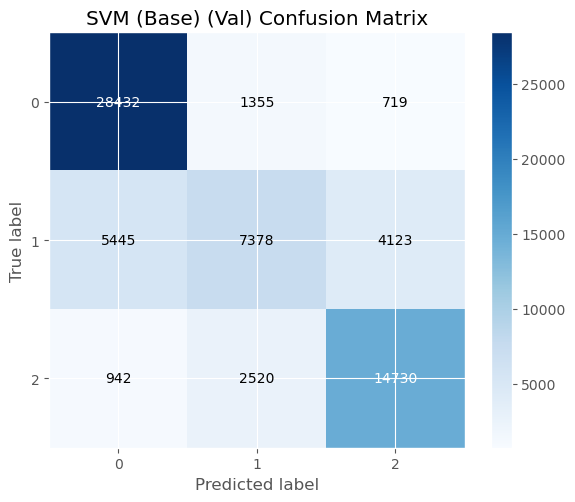

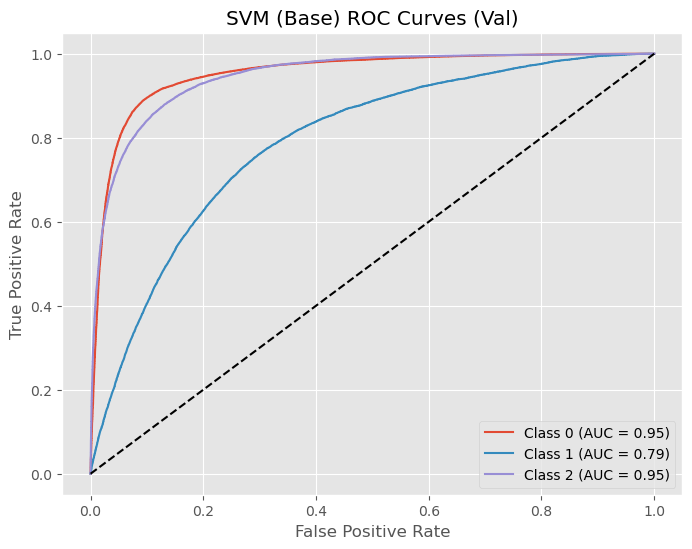

Macro-average ROC AUC (Val): 0.897


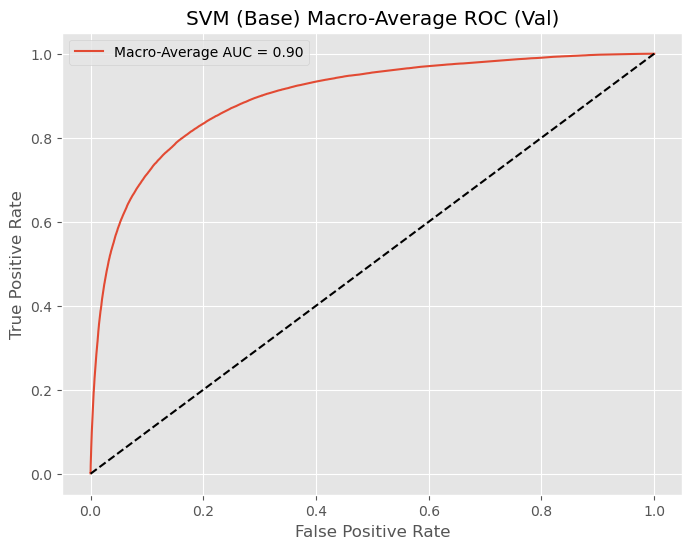

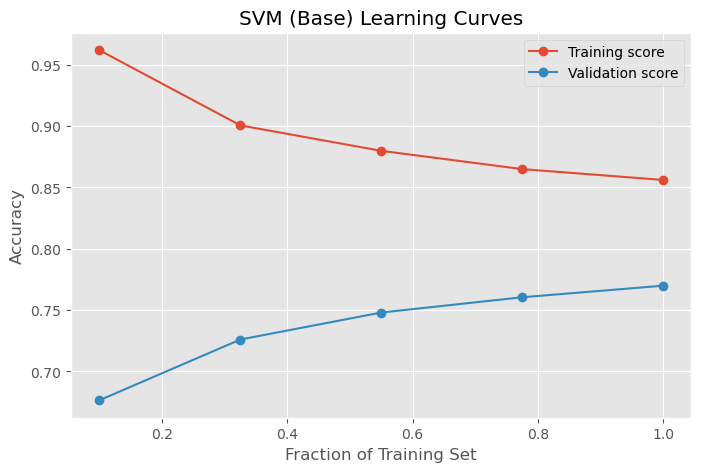


=== SVM: Hyperparameter Tuning ===


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:08<00:00,  8.58s/it]


Best Parameters: {'C': 1, 'max_iter': 1000}
Best CV Score (f1_weighted): 0.739

--- Training SVM (Tuned) ---


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.10s/it]


SVM (Tuned) Accuracy (Val): 0.770
SVM (Tuned) Classification Report (Val):
              precision    recall  f1-score   support

           0       0.82      0.93      0.87     30506
           1       0.66      0.44      0.52     16946
           2       0.75      0.81      0.78     18192

    accuracy                           0.77     65644
   macro avg       0.74      0.73      0.72     65644
weighted avg       0.76      0.77      0.76     65644



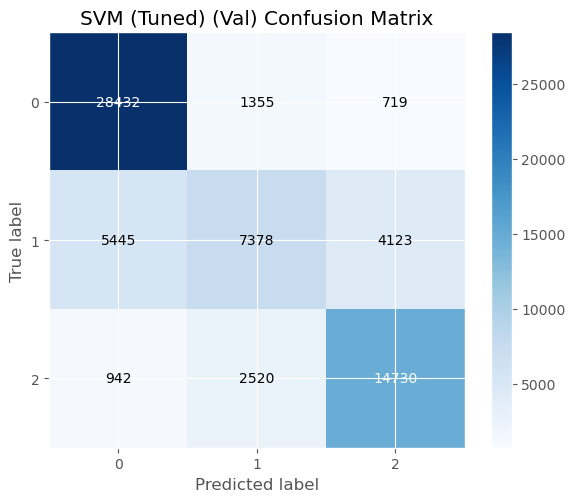

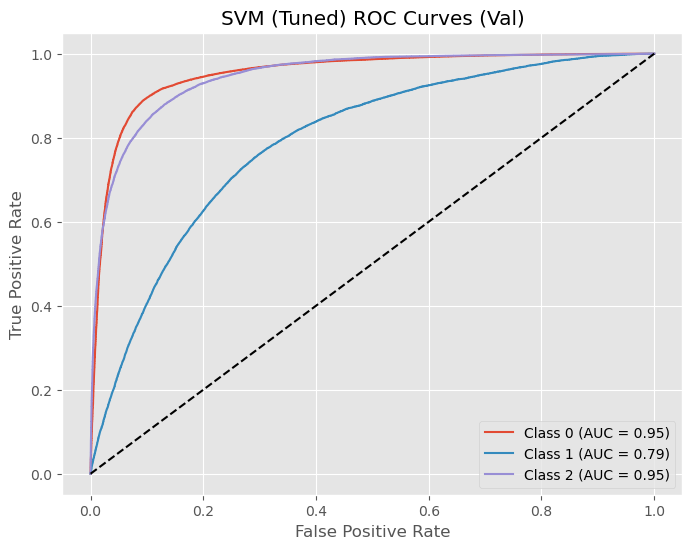

Macro-average ROC AUC (Val): 0.897


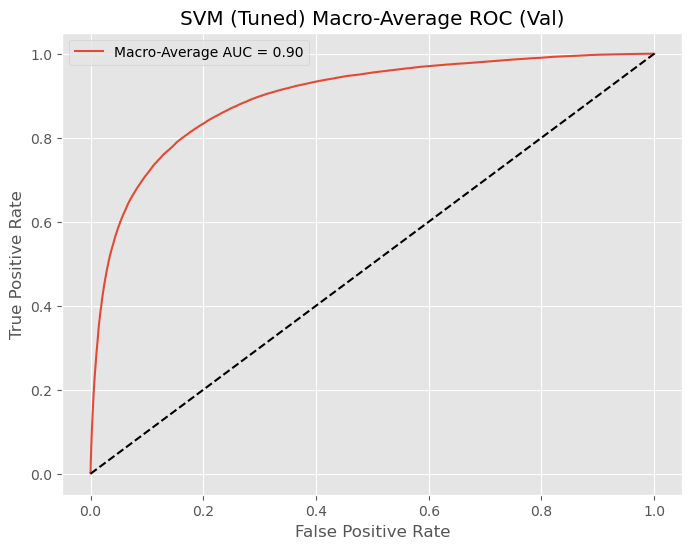

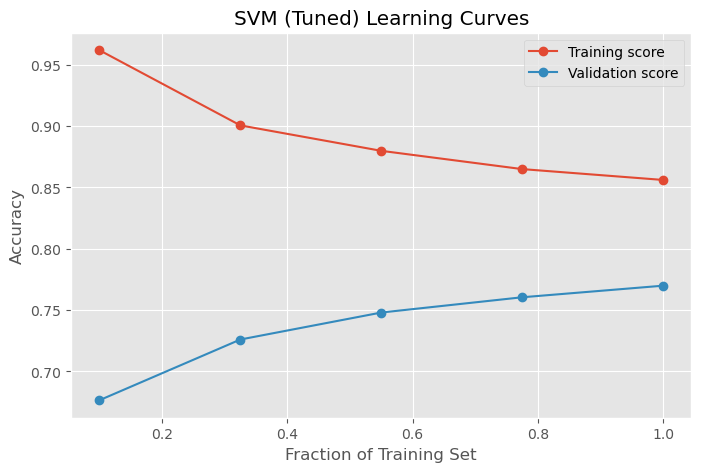


SVM AUC Comparison:
  Base Model  - AUC: 0.897
  Tuned Model - AUC: 0.897

Processing Logistic Regression ...

=== Logistic Regression: Base Model ===

--- Training Logistic Regression (Base) ---


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.67s/it]


Logistic Regression (Base) Accuracy (Val): 0.771
Logistic Regression (Base) Classification Report (Val):
              precision    recall  f1-score   support

           0       0.81      0.93      0.87     30506
           1       0.65      0.50      0.56     16946
           2       0.79      0.76      0.77     18192

    accuracy                           0.77     65644
   macro avg       0.75      0.73      0.73     65644
weighted avg       0.76      0.77      0.76     65644



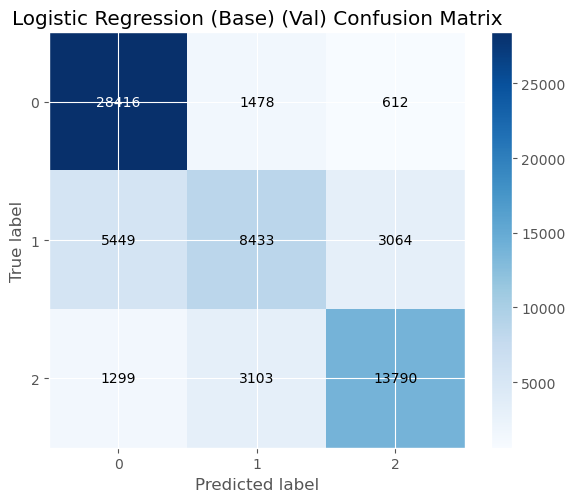

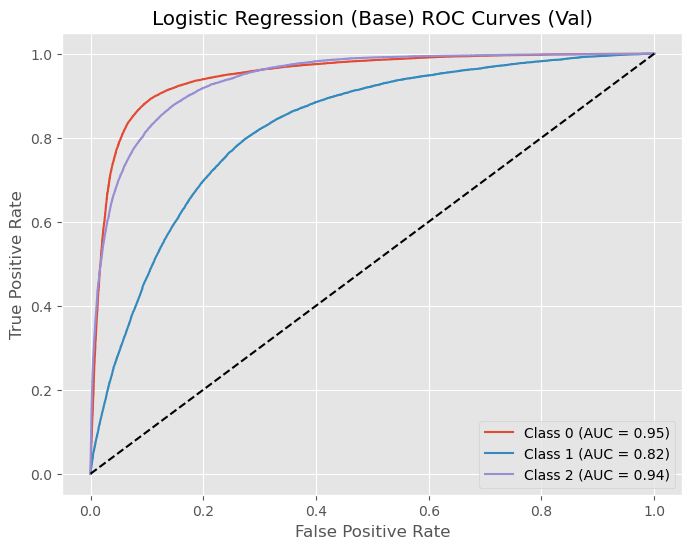

Macro-average ROC AUC (Val): 0.905


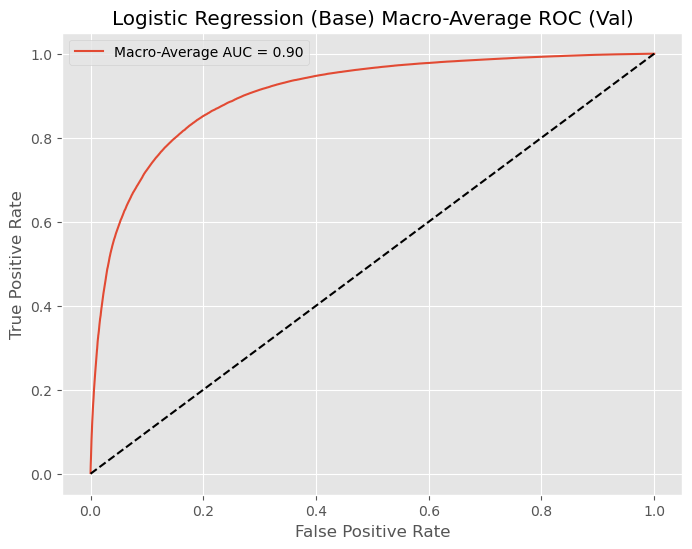

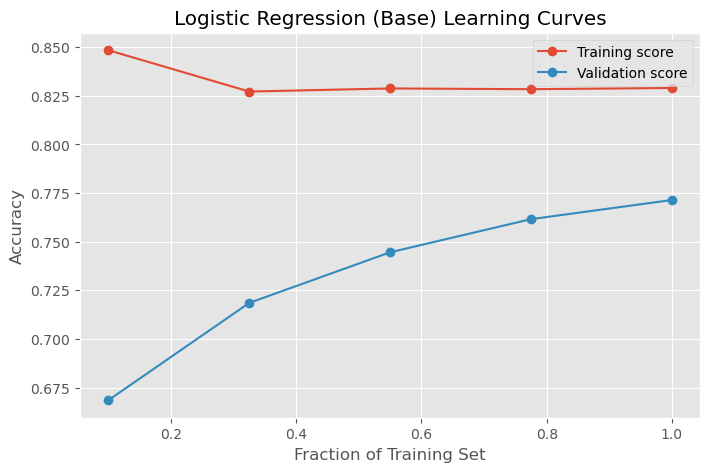


=== Logistic Regression: Hyperparameter Tuning ===


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:08<00:00,  8.26s/it]


Best Parameters: {'C': 10, 'solver': 'lbfgs'}
Best CV Score (f1_weighted): 0.769

--- Training Logistic Regression (Tuned) ---


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.08s/it]


Logistic Regression (Tuned) Accuracy (Val): 0.792
Logistic Regression (Tuned) Classification Report (Val):
              precision    recall  f1-score   support

           0       0.85      0.91      0.88     30506
           1       0.65      0.59      0.62     16946
           2       0.80      0.78      0.79     18192

    accuracy                           0.79     65644
   macro avg       0.77      0.76      0.76     65644
weighted avg       0.79      0.79      0.79     65644



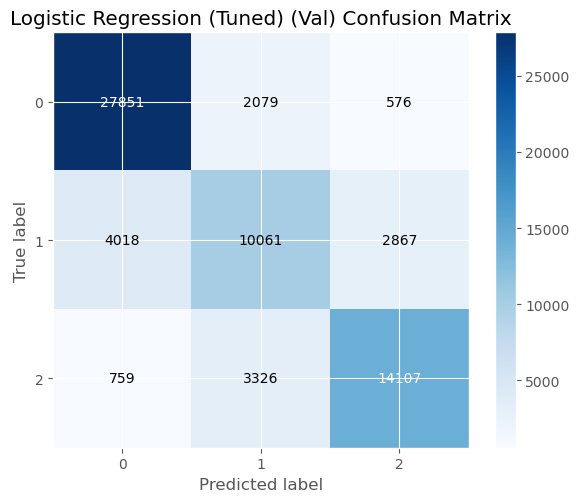

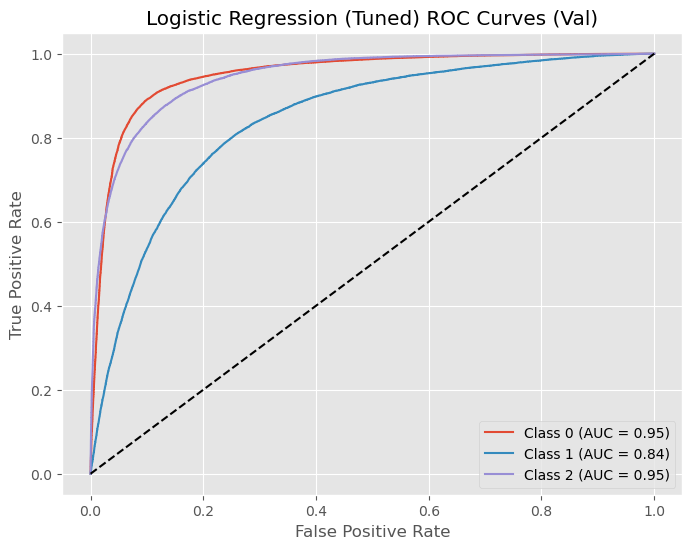

Macro-average ROC AUC (Val): 0.913


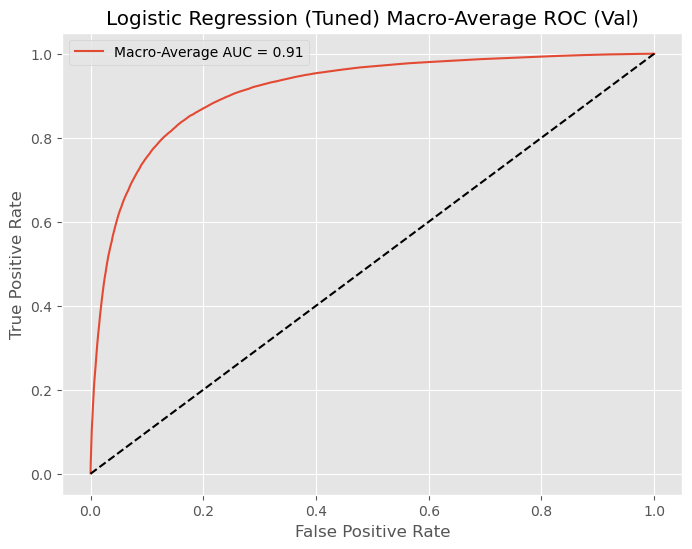

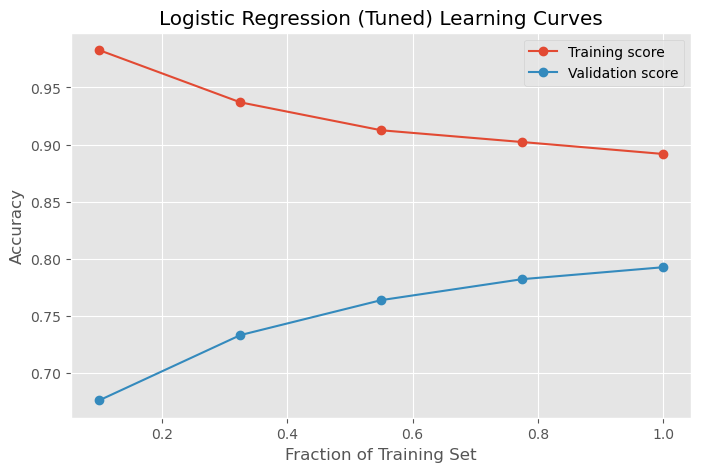


Logistic Regression AUC Comparison:
  Base Model  - AUC: 0.905
  Tuned Model - AUC: 0.913

Processing Naive Bayes ...

=== Naive Bayes: Base Model ===

--- Training Naive Bayes (Base) ---


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 83.25it/s]

Naive Bayes (Base) Accuracy (Val): 0.666
Naive Bayes (Base) Classification Report (Val):
              precision    recall  f1-score   support

           0       0.68      0.95      0.79     30506
           1       0.50      0.17      0.26     16946
           2       0.70      0.65      0.67     18192

    accuracy                           0.67     65644
   macro avg       0.62      0.59      0.57     65644
weighted avg       0.64      0.67      0.62     65644



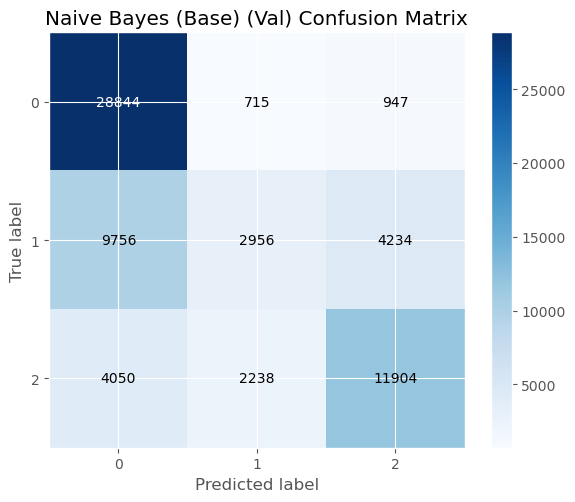

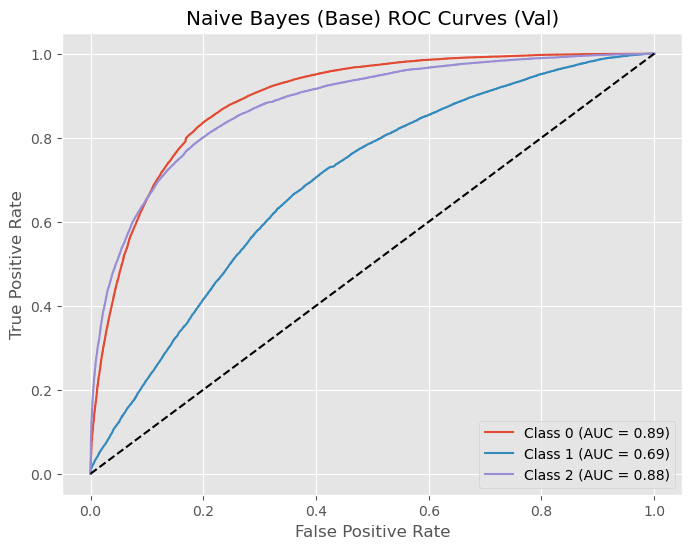

Macro-average ROC AUC (Val): 0.822


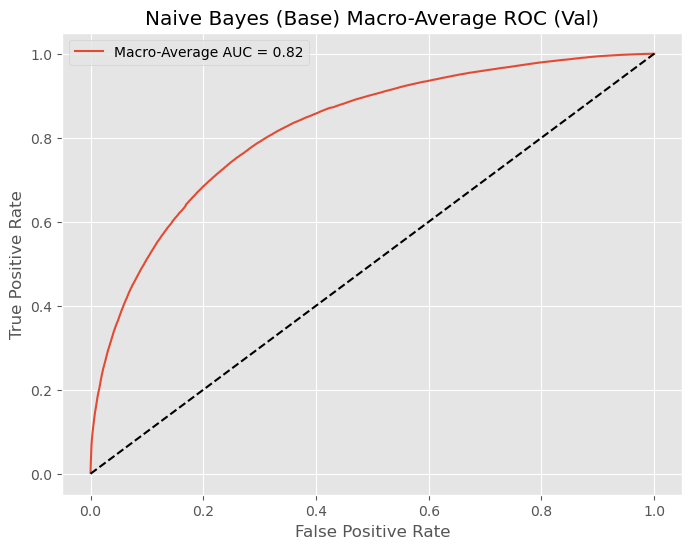

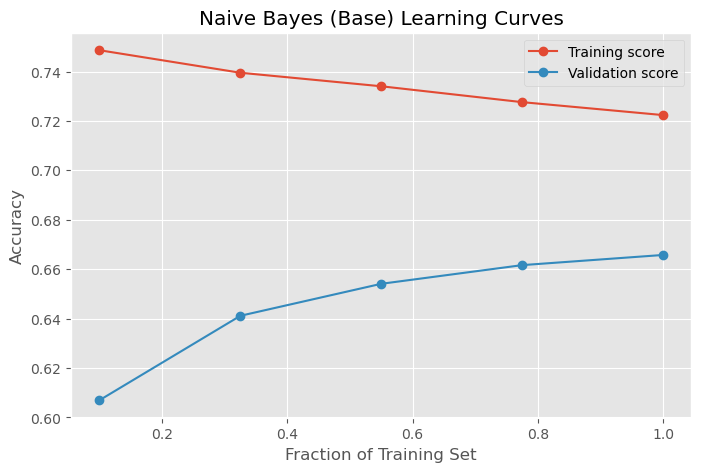


=== Naive Bayes: Hyperparameter Tuning ===


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.13it/s]


Best Parameters: {'alpha': 0.1}
Best CV Score (f1_weighted): 0.612

--- Training Naive Bayes (Tuned) ---


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 78.17it/s]


Naive Bayes (Tuned) Accuracy (Val): 0.656
Naive Bayes (Tuned) Classification Report (Val):
              precision    recall  f1-score   support

           0       0.70      0.90      0.79     30506
           1       0.46      0.24      0.32     16946
           2       0.66      0.63      0.64     18192

    accuracy                           0.66     65644
   macro avg       0.61      0.59      0.58     65644
weighted avg       0.63      0.66      0.63     65644



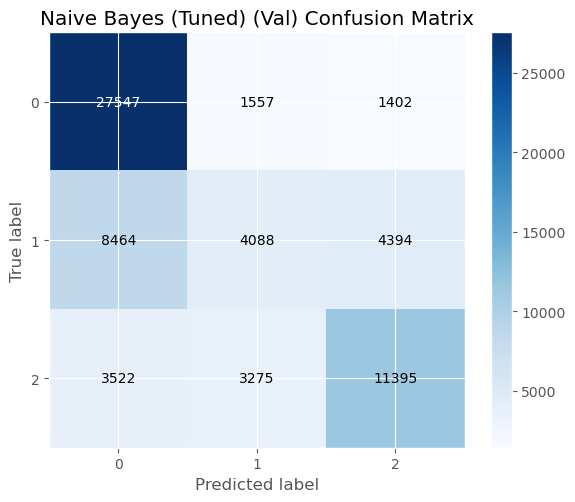

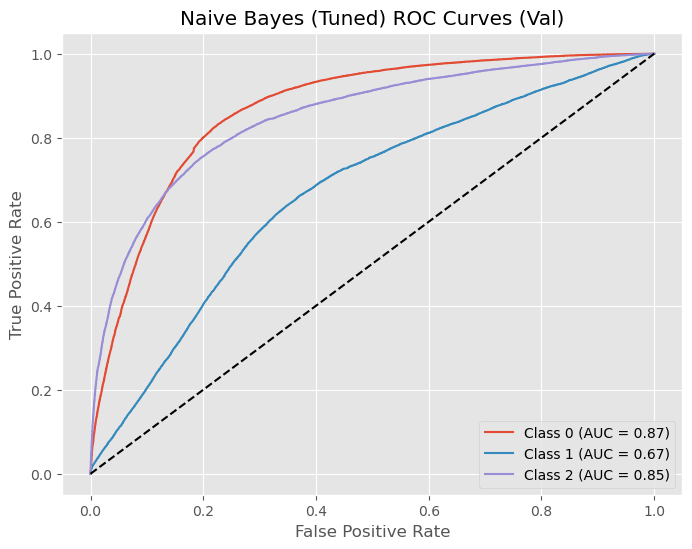

Macro-average ROC AUC (Val): 0.796


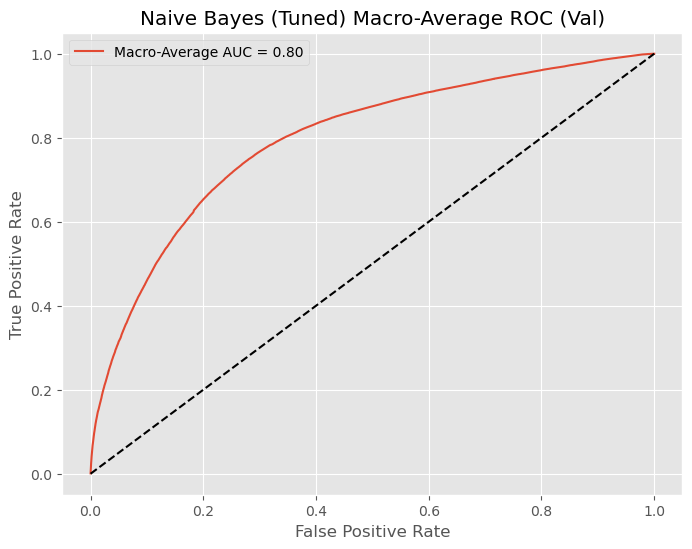

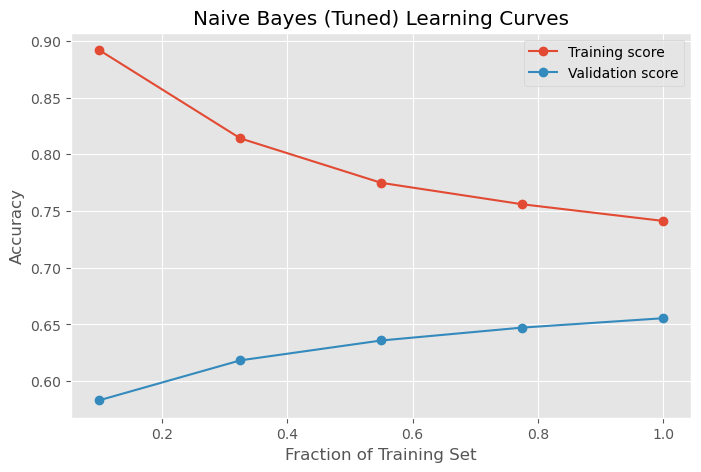


Naive Bayes AUC Comparison:
  Base Model  - AUC: 0.822
  Tuned Model - AUC: 0.796

Processing XGBoost ...

=== XGBoost: Base Model ===


C:\Users\cornelius\anaconda3\envs\notebook\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:07:51] WARNING: C:\b\abs_90_bwj_86a\croot\xgboost-split_1724073762025\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



--- Training XGBoost (Base) ---


  0%|                                                                                            | 0/1 [00:00<?, ?it/s]C:\Users\cornelius\anaconda3\envs\notebook\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:08:17] WARNING: C:\b\abs_90_bwj_86a\croot\xgboost-split_1724073762025\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:26<00:00, 26.76s/it]


XGBoost (Base) Accuracy (Val): 0.716
XGBoost (Base) Classification Report (Val):
              precision    recall  f1-score   support

           0       0.73      0.92      0.81     30506
           1       0.61      0.38      0.47     16946
           2       0.75      0.69      0.72     18192

    accuracy                           0.72     65644
   macro avg       0.70      0.66      0.67     65644
weighted avg       0.70      0.72      0.70     65644



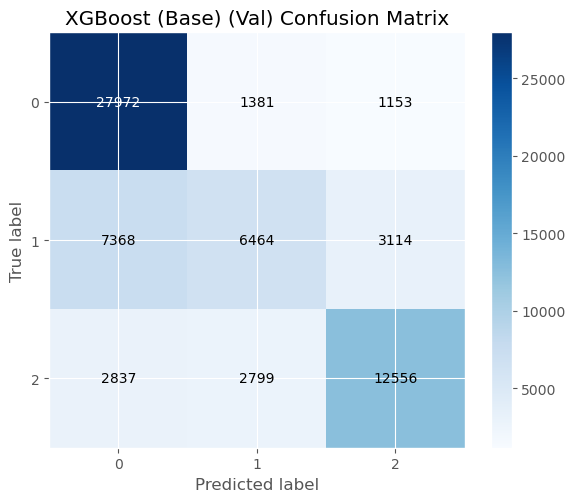

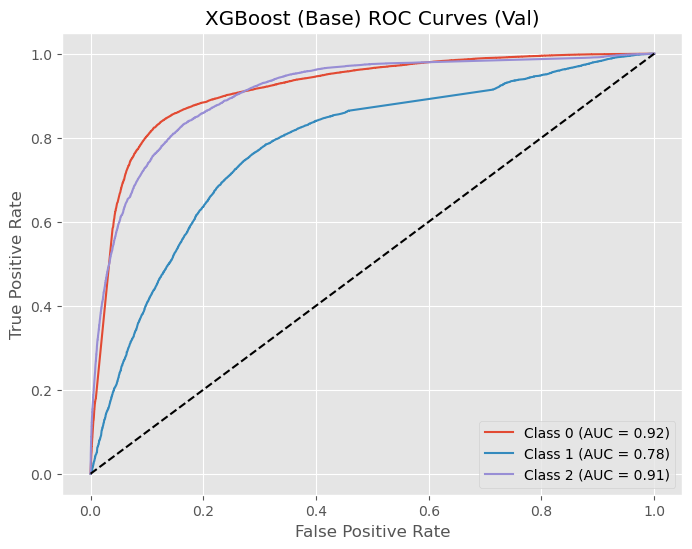

Macro-average ROC AUC (Val): 0.869


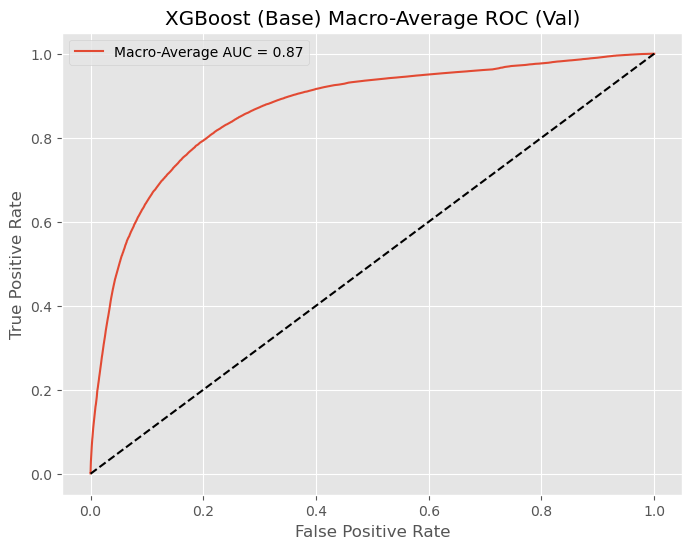

C:\Users\cornelius\anaconda3\envs\notebook\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:08:44] WARNING: C:\b\abs_90_bwj_86a\croot\xgboost-split_1724073762025\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\cornelius\anaconda3\envs\notebook\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:08:47] WARNING: C:\b\abs_90_bwj_86a\croot\xgboost-split_1724073762025\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\cornelius\anaconda3\envs\notebook\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:08:57] WARNING: C:\b\abs_90_bwj_86a\croot\xgboost-split_1724073762025\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\cornelius\anaconda3\envs\notebook\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:09:13] WARNING: C:\b\abs_90_bwj_86a\croot\xgboost-split_17

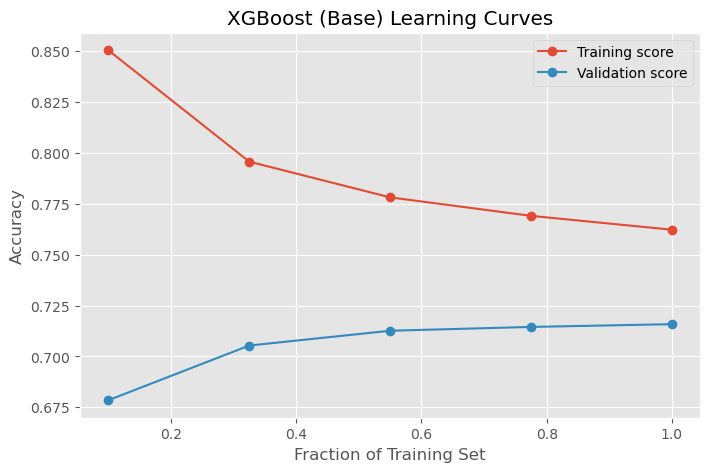


=== XGBoost: Hyperparameter Tuning ===


  0%|                                                                                            | 0/1 [00:00<?, ?it/s]C:\Users\cornelius\anaconda3\envs\notebook\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:16:19] WARNING: C:\b\abs_90_bwj_86a\croot\xgboost-split_1724073762025\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
100%|███████████████████████████████████████████████████████████████████████████████████| 1/1 [07:26<00:00, 446.87s/it]


Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
Best CV Score (f1_weighted): 0.684

--- Training XGBoost (Tuned) ---


  0%|                                                                                            | 0/1 [00:00<?, ?it/s]C:\Users\cornelius\anaconda3\envs\notebook\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:17:25] WARNING: C:\b\abs_90_bwj_86a\croot\xgboost-split_1724073762025\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [01:03<00:00, 63.93s/it]


XGBoost (Tuned) Accuracy (Val): 0.703
XGBoost (Tuned) Classification Report (Val):
              precision    recall  f1-score   support

           0       0.72      0.92      0.80     30506
           1       0.60      0.35      0.44     16946
           2       0.74      0.68      0.70     18192

    accuracy                           0.70     65644
   macro avg       0.68      0.65      0.65     65644
weighted avg       0.69      0.70      0.68     65644



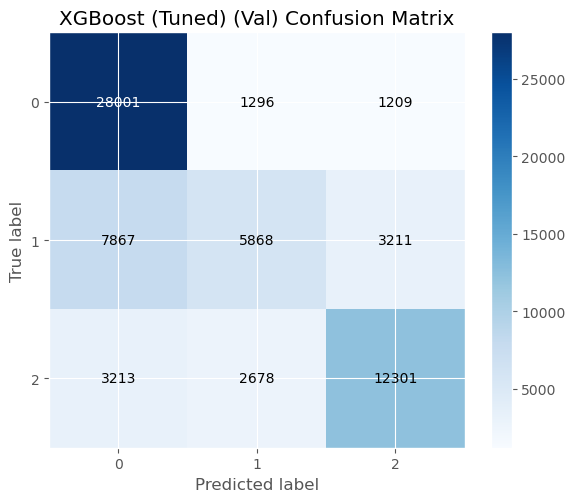

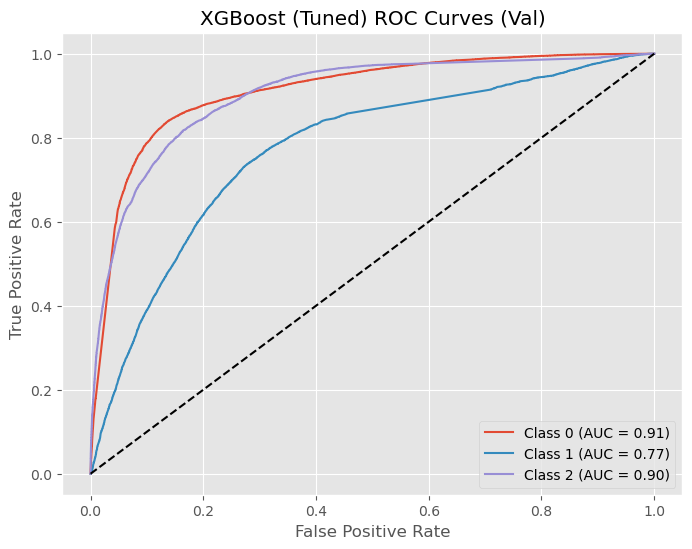

Macro-average ROC AUC (Val): 0.862


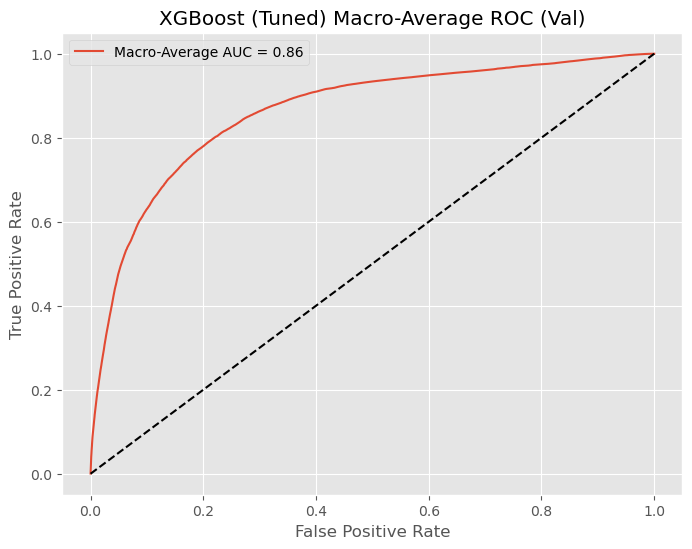

C:\Users\cornelius\anaconda3\envs\notebook\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:18:30] WARNING: C:\b\abs_90_bwj_86a\croot\xgboost-split_1724073762025\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\cornelius\anaconda3\envs\notebook\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:18:37] WARNING: C:\b\abs_90_bwj_86a\croot\xgboost-split_1724073762025\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\cornelius\anaconda3\envs\notebook\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:19:01] WARNING: C:\b\abs_90_bwj_86a\croot\xgboost-split_1724073762025\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\cornelius\anaconda3\envs\notebook\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:19:38] WARNING: C:\b\abs_90_bwj_86a\croot\xgboost-split_17

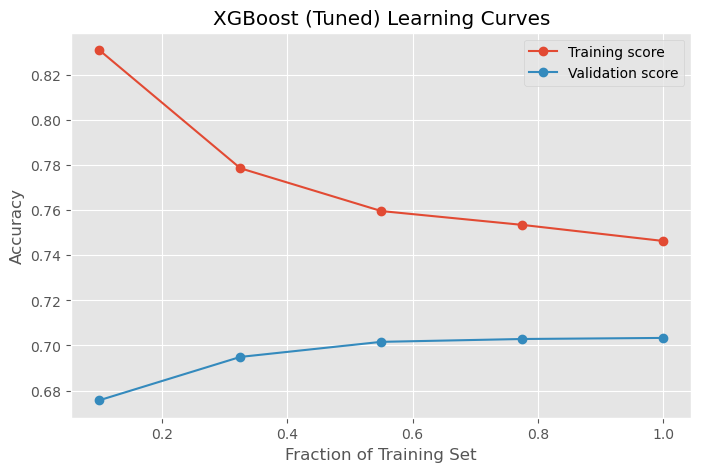


XGBoost AUC Comparison:
  Base Model  - AUC: 0.869
  Tuned Model - AUC: 0.862

=== Final Model Comparison on Test Set ===

--- SVM on TEST SET ---
Accuracy (Test): 0.769
Classification Report (Test):
              precision    recall  f1-score   support

           0       0.82      0.93      0.87     26148
           1       0.65      0.43      0.52     14526
           2       0.75      0.81      0.78     15593

    accuracy                           0.77     56267
   macro avg       0.74      0.72      0.72     56267
weighted avg       0.76      0.77      0.75     56267



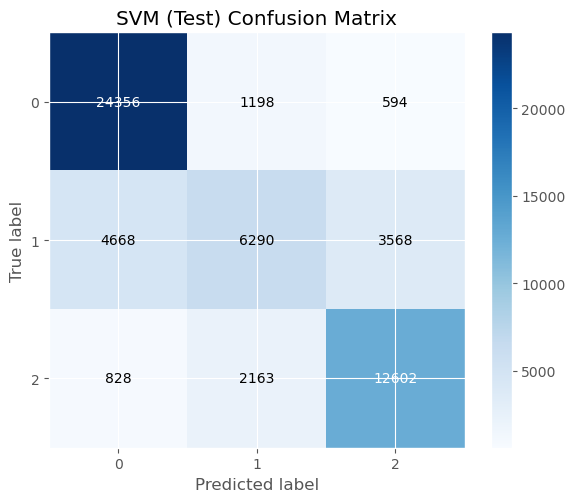

SVM Macro-Average AUC (Test): 0.895

--- Logistic Regression on TEST SET ---
Accuracy (Test): 0.792
Classification Report (Test):
              precision    recall  f1-score   support

           0       0.85      0.91      0.88     26148
           1       0.65      0.59      0.62     14526
           2       0.80      0.77      0.79     15593

    accuracy                           0.79     56267
   macro avg       0.77      0.76      0.76     56267
weighted avg       0.79      0.79      0.79     56267



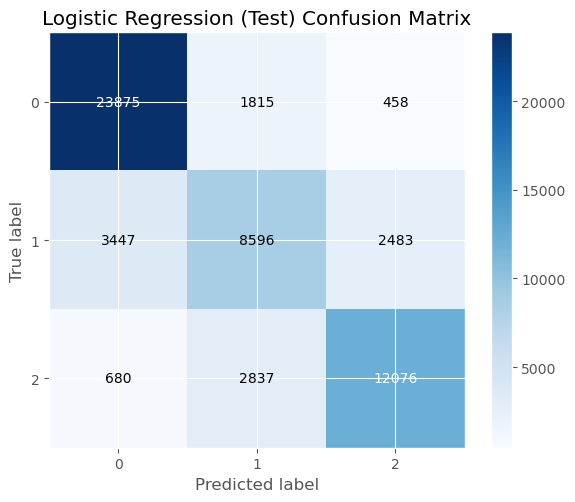

Logistic Regression Macro-Average AUC (Test): 0.912

--- Naive Bayes on TEST SET ---
Accuracy (Test): 0.653
Classification Report (Test):
              precision    recall  f1-score   support

           0       0.69      0.90      0.78     26148
           1       0.46      0.24      0.31     14526
           2       0.66      0.62      0.64     15593

    accuracy                           0.65     56267
   macro avg       0.60      0.59      0.58     56267
weighted avg       0.62      0.65      0.62     56267



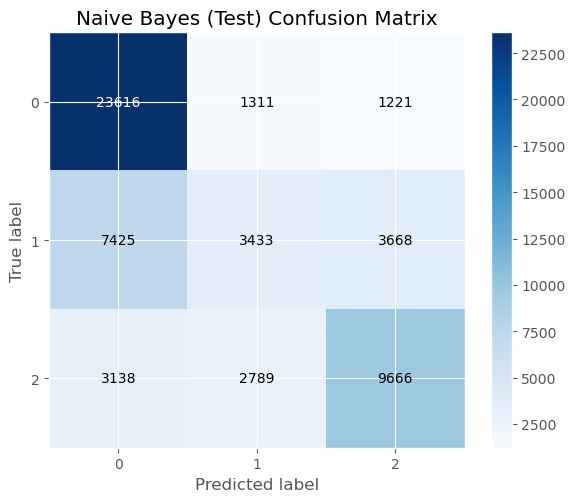

Naive Bayes Macro-Average AUC (Test): 0.793

--- XGBoost on TEST SET ---
Accuracy (Test): 0.705
Classification Report (Test):
              precision    recall  f1-score   support

           0       0.72      0.92      0.81     26148
           1       0.60      0.35      0.44     14526
           2       0.74      0.67      0.70     15593

    accuracy                           0.71     56267
   macro avg       0.68      0.65      0.65     56267
weighted avg       0.69      0.71      0.68     56267



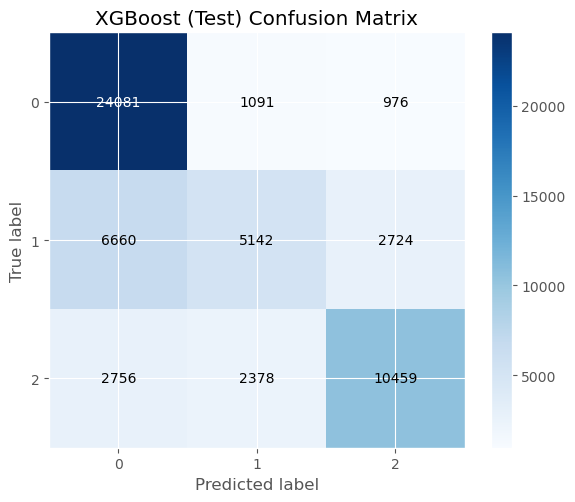

XGBoost Macro-Average AUC (Test): 0.862

--- Final Macro-Average AUC (Test) ---
SVM: 0.895
Logistic Regression: 0.912
Naive Bayes: 0.793
XGBoost: 0.862

========== RUNNING LSTM PIPELINE ==========

--- LSTM Pipeline ---


C:\Users\cornelius\anaconda3\envs\notebook\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



[LSTM] Epoch 1/5


  Train Loss: 1.0631, Train Acc: 0.4641
  Val   Loss: 1.0617, Val   Acc: 0.4647

[LSTM] Epoch 2/5


  Train Loss: 1.0623, Train Acc: 0.4647
  Val   Loss: 1.0616, Val   Acc: 0.4647

[LSTM] Epoch 3/5


  Train Loss: 1.0619, Train Acc: 0.4647
  Val   Loss: 1.0622, Val   Acc: 0.4647

[LSTM] Epoch 4/5


  Train Loss: 1.0618, Train Acc: 0.4647
  Val   Loss: 1.0615, Val   Acc: 0.4647

[LSTM] Epoch 5/5


  Train Loss: 1.0617, Train Acc: 0.4647
  Val   Loss: 1.0621, Val   Acc: 0.4647


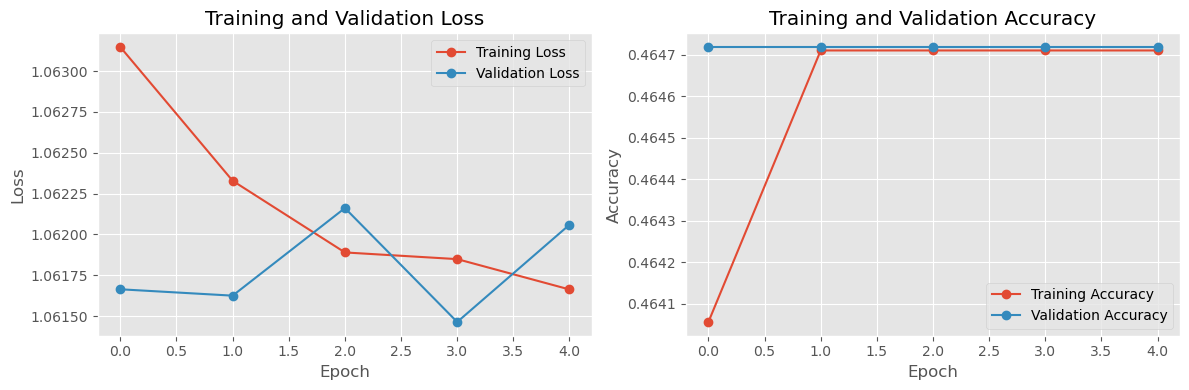


[LSTM] Test Loss: 1.0621, Test Accuracy: 0.4647

[LSTM] Classification Report (Test):
              precision    recall  f1-score   support

         bad       0.46      1.00      0.63     26148
     neutral       0.00      0.00      0.00     14526
        good       0.00      0.00      0.00     15593

    accuracy                           0.46     56267
   macro avg       0.15      0.33      0.21     56267
weighted avg       0.22      0.46      0.29     56267



C:\Users\cornelius\anaconda3\envs\notebook\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\cornelius\anaconda3\envs\notebook\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\cornelius\anaconda3\envs\notebook\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

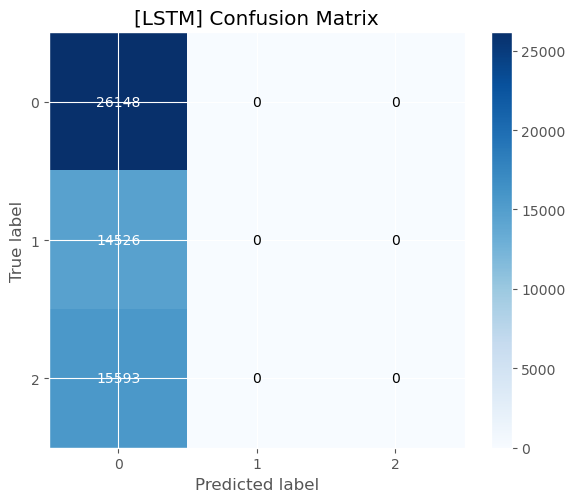


========== RUNNING CNN PIPELINE ==========

--- CNN Pipeline ---


C:\Users\cornelius\anaconda3\envs\notebook\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



[CNN] Epoch 1/5


  Train Loss: 0.8708, Train Acc: 0.6024
  Val   Loss: 0.6782, Val   Acc: 0.7060

[CNN] Epoch 2/5


  Train Loss: 0.6488, Train Acc: 0.7255
  Val   Loss: 0.5773, Val   Acc: 0.7630

[CNN] Epoch 3/5


  Train Loss: 0.5438, Train Acc: 0.7797
  Val   Loss: 0.5354, Val   Acc: 0.7890

[CNN] Epoch 4/5


  Train Loss: 0.4830, Train Acc: 0.8091
  Val   Loss: 0.5408, Val   Acc: 0.7957

[CNN] Epoch 5/5


  Train Loss: 0.4280, Train Acc: 0.8344
  Val   Loss: 0.5458, Val   Acc: 0.7954


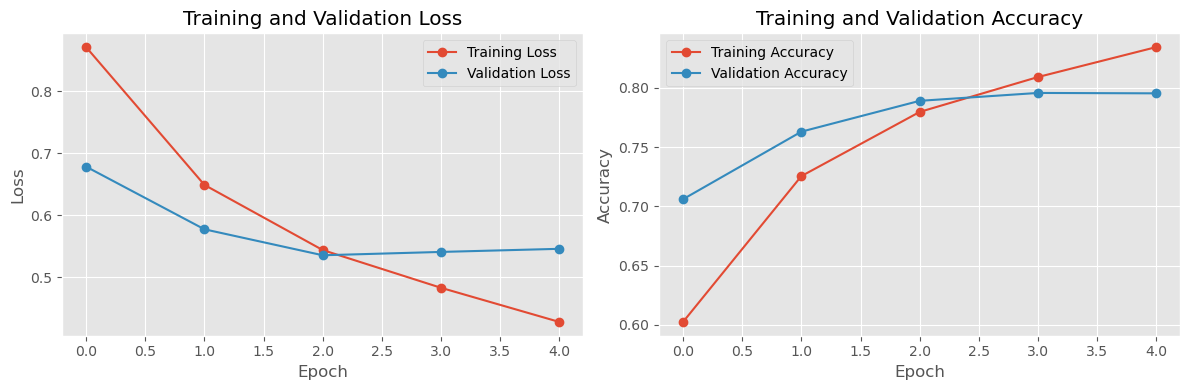


[CNN] Test Loss: 0.5504, Test Accuracy: 0.7940

[CNN] Classification Report (Test):
              precision    recall  f1-score   support

         bad       0.88      0.90      0.89     26148
     neutral       0.61      0.70      0.65     14526
        good       0.86      0.71      0.78     15593

    accuracy                           0.79     56267
   macro avg       0.78      0.77      0.77     56267
weighted avg       0.80      0.79      0.80     56267



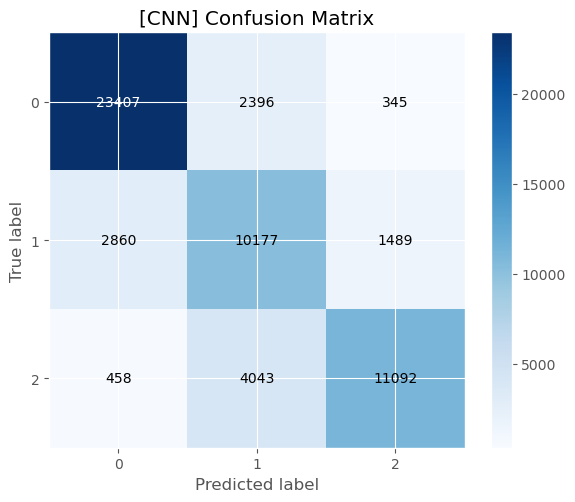


========== RUNNING bert PIPELINE ==========

--- bert Pipeline ---


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\cornelius\anaconda3\envs\notebook\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



[bert] Epoch 1/3


  Train Loss: 0.5203, Train Acc: 0.7880
  Val   Loss: 0.4750, Val   Acc: 0.8236

[bert] Epoch 2/3


  Train Loss: 0.3648, Train Acc: 0.8648
  Val   Loss: 0.3836, Val   Acc: 0.8610

[bert] Epoch 3/3


  Train Loss: 0.2842, Train Acc: 0.8965
  Val   Loss: 0.4217, Val   Acc: 0.8520


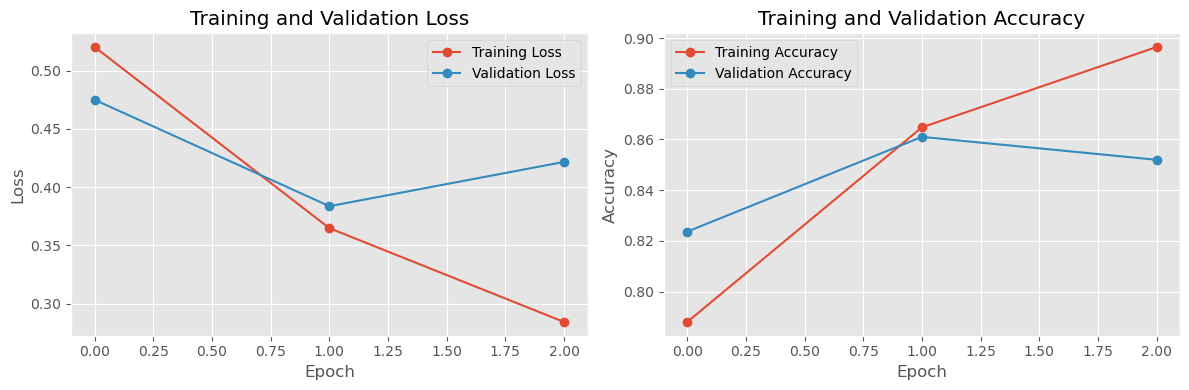


[bert] Test Accuracy: 0.8506

[bert] Classification Report (Test):
              precision    recall  f1-score   support

         bad       0.93      0.90      0.91     26148
     neutral       0.75      0.71      0.73     14526
        good       0.82      0.90      0.86     15593

    accuracy                           0.85     56267
   macro avg       0.83      0.84      0.83     56267
weighted avg       0.85      0.85      0.85     56267



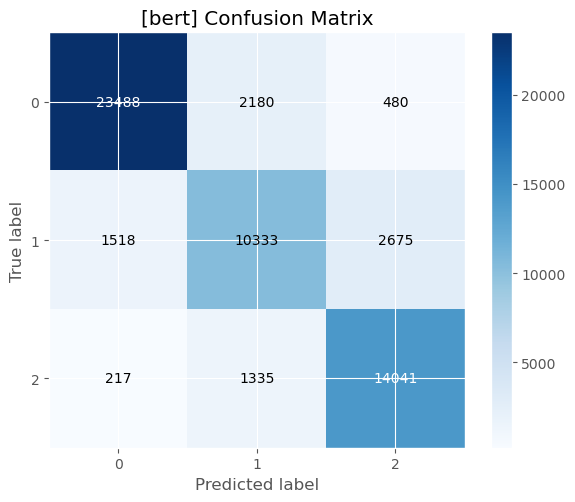


========== RUNNING Roberta PIPELINE ==========

--- RoBERTa Pipeline ---


C:\Users\cornelius\anaconda3\envs\notebook\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



[RoBERTa] Epoch 1/3


  Train Loss: 0.5910, Train Acc: 0.7609
  Val   Loss: 0.4547, Val   Acc: 0.8290

[RoBERTa] Epoch 2/3


  Train Loss: 0.4537, Train Acc: 0.8377
  Val   Loss: 0.5367, Val   Acc: 0.8258

[RoBERTa] Epoch 3/3


  Train Loss: 0.4158, Train Acc: 0.8622
  Val   Loss: 0.5039, Val   Acc: 0.8486


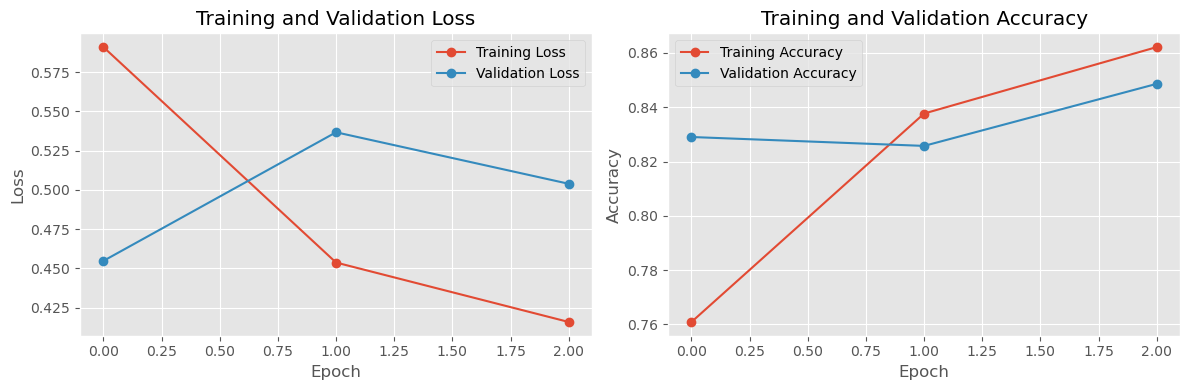


[RoBERTa] Test Accuracy: 0.8482
[RoBERTa] Classification Report (Test):
              precision    recall  f1-score   support

         bad       0.89      0.93      0.91     26148
     neutral       0.74      0.71      0.73     14526
        good       0.88      0.83      0.85     15593

    accuracy                           0.85     56267
   macro avg       0.83      0.83      0.83     56267
weighted avg       0.85      0.85      0.85     56267



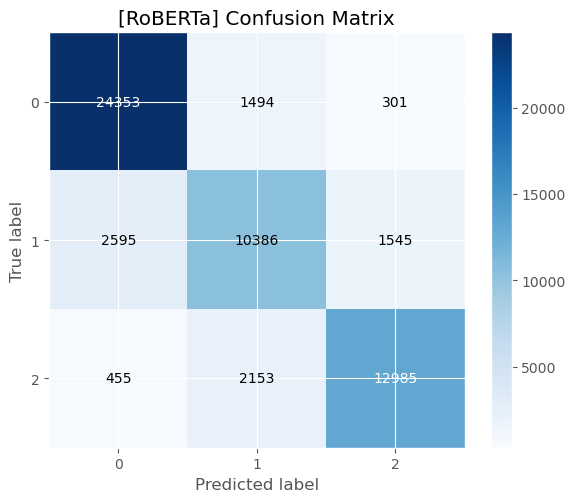


All modeling pipelines completed.


In [ ]:
if __name__ == "__main__":
    # 1) Run ML Models
    print("\n========== RUNNING ML MODELS ==========")
    best_models, final_results = run_classical_models(X_train, X_val, X_test, y_train, y_val, y_test)

    # 2) Run LSTM
    print("\n========== RUNNING LSTM PIPELINE ==========")
    run_lstm_pipeline()

    # 3) Run CNN
    print("\n========== RUNNING CNN PIPELINE ==========")
    run_cnn_pipeline()

    # 4) Run bert
    print("\n========== RUNNING bert PIPELINE ==========")
    run_bert_pipeline()

    # 5) Run Roberta
    print("\n========== RUNNING Roberta PIPELINE ==========")
    run_roberta_pipeline()

    print("\nAll modeling pipelines completed.")

### Comparison Table

![Model Overview](Models.png "Visualization of the Models")

[Download the file from Google Drive](https://drive.google.com/file/d/1FF4tZrZ8v4Ia5sokUSAYqDVpgIurZpSl/view?usp=sharing)


# Analisis Per Kelas Sentimen

## Kelas "Bad" (Sentimen Negatif)

### Performa Terbaik:
- **BERT**: Precision 0.93, Recall 0.90, F1-Score 0.91  
- **RoBERTa**: Precision 0.89, Recall 0.93, F1-Score 0.91  
- **CNN**: Precision 0.88, Recall 0.90, F1-Score 0.89  

### Performa Menengah:
- **Logistic Regression**: Precision 0.85, Recall 0.91, F1-Score 0.88  
- **SVM**: Precision 0.82, Recall 0.93, F1-Score 0.87  
- **XGBoost**: Precision 0.72, Recall 0.92, F1-Score 0.81  

### Performa Terendah:
- **Naive Bayes**: Precision 0.69, Recall 0.90, F1-Score 0.78  
- **LSTM**: Precision 0.46, Recall 1.00, F1-Score 0.63  

### Insight:
- Semua model menunjukkan recall tinggi untuk sentimen negatif.  
- Model transformer memiliki keseimbangan terbaik antara precision dan recall.  
- LSTM memiliki recall sempurna tapi precision rendah, menunjukkan over-prediction kelas negatif.  

---

## Kelas "Neutral"

### Performa Terbaik:
- **BERT**: Precision 0.75, Recall 0.71, F1-Score 0.73  
- **RoBERTa**: Precision 0.74, Recall 0.71, F1-Score 0.73  
- **CNN**: Precision 0.61, Recall 0.70, F1-Score 0.65  

### Performa Menengah:
- **Logistic Regression**: Precision 0.65, Recall 0.59, F1-Score 0.62  
- **SVM**: Precision 0.65, Recall 0.43, F1-Score 0.52  

### Performa Terendah:
- **XGBoost**: Precision 0.60, Recall 0.35, F1-Score 0.44  
- **Naive Bayes**: Precision 0.46, Recall 0.24, F1-Score 0.31  
- **LSTM**: Precision 0, Recall 0, F1-Score 0  

### Insight:
- Kelas neutral paling sulit dideteksi oleh semua model.  
- Model transformer menunjukkan performa jauh lebih baik.  
- LSTM gagal total dalam mendeteksi sentimen neutral.  
- Model tradisional struggle dengan recall rendah.  

---

## Kelas "Good" (Sentimen Positif)

### Performa Terbaik:
- **RoBERTa**: Precision 0.83, Recall 0.83, F1-Score 0.83  
- **BERT**: Precision 0.82, Recall 0.90, F1-Score 0.86  
- **CNN**: Precision 0.86, Recall 0.71, F1-Score 0.78  

### Performa Menengah:
- **Logistic Regression**: Precision 0.80, Recall 0.77, F1-Score 0.79  
- **SVM**: Precision 0.75, Recall 0.81, F1-Score 0.78  
- **XGBoost**: Precision 0.74, Recall 0.67, F1-Score 0.70  

### Performa Terendah:
- **Naive Bayes**: Precision 0.66, Recall 0.62, F1-Score 0.64  
- **LSTM**: Precision 0, Recall 0, F1-Score 0  

### Insight:
- Model transformer menunjukkan keseimbangan terbaik untuk sentimen positif.  
- CNN memiliki precision tinggi tapi recall lebih rendah.  
- Model tradisional menunjukkan performa yang cukup konsisten.  
- LSTM kembali gagal mendeteksi kelas ini.  

---

## Kesimpulan Analisis Per Kelas:

- Sentimen negatif ("Bad") paling mudah dideteksi oleh semua model.  
- Sentimen neutral paling menantang untuk semua model.  
- Model transformer konsisten unggul di semua kelas.  
- LSTM menunjukkan masalah serius dalam klasifikasi multi-kelas.  
- Untuk implemntasi aplikasi yang fokus pada deteksi sentimen negatif, model yang lebih sederhana seperti SVM dan Logistic Regression bisa dipertimbangkan.
- Untuk kasus yang membutuhkan deteksi sentimen neutral yang akurat, model transformer adalah pilihan terbaik.    

---
# Analisis Keseluruhan

## Konteks dan Latar Belakang
- **Analisis sentimen** adalah metode untuk memahami emosi dan opini manusia dari teks, khususnya dalam interaksi manusia-AI.  
- **EDA** mengungkapkan pola kata kunci berikut:  
  - Sentimen negatif: *"Not," "Think," "New"*.  
  - Sentimen positif: *"Like," "Use," "Good"*.  
- Pola ini menjadi dasar pemilihan model prediktif yang digunakan.

---

## Evaluasi Performa Model

### Model Transformer (BERT & RoBERTa)
- **Akurasi tertinggi**: 0.85.  
- **F1-Score**: 0.91 untuk kelas *"Bad"*.  
- **Recall tinggi**: 0.90-0.93 untuk sentimen negatif.  
- **RoBERTa** lebih efisien dengan batch size yang lebih kecil.  
- **Arsitektur bidirectional** mendukung pemahaman konteks yang lebih baik.

### Model Tradisional
- **CNN & Logistic Regression**: Performa kompetitif dengan akurasi 0.79.  
- **SVM**: Akurasi 0.77 dengan performa seimbang.  
- **XGBoost**: Akurasi menengah (0.71), tetapi lemah pada kelas *neutral*.  
- **Naive Bayes**: Performa lebih rendah (0.65).  
- **LSTM**: Performa terburuk (0.46), membutuhkan evaluasi ulang.

---

## Insights
1. **BERT/RoBERTa** untuk hasil yang paling akurat karena kemampuan Masked Language Modeling (MLM) dan Next Sentence Prediction (NSP).  
2. **CNN/Logistic Regression** sebagai alternatif hemat resource.  
3. **Mengoptimasi ulang hyperparameter**, terutama untuk LSTM.  
4. Mengevaluasi dampak **class imbalance** pada model.

---

## Arah Pengembangan Masa Depan
1. **Integrasi data multimodal** (teks, visual, audio) untuk memperkaya analisis.  
2. Eksplorasi **ModernBERT** untuk peningkatan performa.

---

## Kesimpulan
Penelitian ini menunjukkan keunggulan model transformer dalam analisis sentimen, dengan **BERT dan RoBERTa** menunjukkan performa terbaik.  
- Meski **model tradisional** tetap kompetitif untuk tugas tertentu, adopsi model yang lebih **sophisticated** seperti **ModernBERT** menjadi kebutuhan untuk menangani kompleksitas sentimen dalam interaksi manusia-AI.  
- Tantangan utama adalah optimasi model untuk **klasifikasi sentimen netral** dan pengembangan sistem yang dapat mengintegrasikan berbagai modalitas data sambil tetap mempertahankan prinsip **fairness** dan **keterbukaan**.
- Fairness dalam konteks ini berarti memastikan model tidak bias terhadap kelompok tertentu, seperti gender, suku, atau budaya. Misalnya, model harus mampu mengenali sentimen secara objektif, tanpa mengabaikan atau salah mengklasifikasikan teks dari kelompok minoritas.
- Keterbukaan berarti sistem harus dapat dijelaskan dan dipahami oleh pengguna. Misalnya, pengguna harus tahu mengapa suatu teks diklasifikasikan sebagai positif, negatif, atau netral, dan model harus transparan tentang keterbatasannya, seperti kesulitan mengenali sarkasme.